# Manuscript figures

In [1]:
%load_ext autoreload
%autoreload 2

import os
# only load this one time per session
if 'NOTEBOOK_INITIALIZED' not in globals():
    os.chdir(os.path.dirname(os.path.abspath('.')))
    NOTEBOOK_INITIALIZED = True

import seaborn as sns
import matplotlib.pyplot as plt
import pooch
import pandas as pd
from tqdm import tqdm
import numpy as np

import src.utils as utils
import src.config as config
import src.haplosaurus as hs
import src.ESM as ESM
import src.ESM_predict as ESMp
import src.gprofiler as gp
import src.vep_pipeline as vp
import src.vep_analysis as va
import src.vep_metrics as vm
import src.proteingym as pg 
import src.ensembl_rest as er
import src.biopython as bp
import src.analysis.distributions as db
import src.analysis.attributions as ab
import src.colabfold.colabfold as cf
import src.benchmark.clinvar as bcv

pd.set_option('display.max_columns', None)

/home/schilder/.conda/envs/esm2/lib/python3.12/site-packages/Bio/Application/__init__.py:39: BiopythonDeprecationWarning: The Bio.Application modules and modules relying on it have been deprecated.

Due to the on going maintenance burden of keeping command line application
wrappers up to date, we have decided to deprecate and eventually remove these
modules.

We instead now recommend building your command line and invoking it directly
with the subprocess module.
  warnings.warn(


## Figure 1

### Figure 1A

![](img/fig1a.png)

### Figure 1B

Import haplotype sequences from Haplosaurus. 
These are the wild-type sequences for each protein that occurs within the 1000 Genomes Project.






In [155]:
proteins_df = pg.merge_resources(rows_per_id=None)

haplotypes_hgdp = hs.get_haplotypes(cache = hs.DIR_DICT["HGDP_haplotypes"],
                                     tx_ids=proteins_df['ENST'].unique(), 
                                    cache_only = True) 
haplotypes_1kg = hs.get_haplotypes(cache = hs.DIR_DICT["haplotypes"],
                                    tx_ids=proteins_df['ENST'].unique(), 
                                    cache_only = True) 
haplotypes = hs.merge_haplotype_datasets({"1KG":haplotypes_1kg, "HGDP":haplotypes_hgdp},
                                         tx_id_method = "union",
                                         use_deepcopy = True) 

Found haplotypes of 85520 transcripts in: '/home/schilder/projects/data/Human_Genome_Diversity_Project/haplosaurus/'


Getting haplotypes:   0%|          | 0/2652 [00:00<?, ?it/s]

Found haplotypes of 47329 transcripts in: '/home/schilder/.cache/ensembl_rest/haplotypes/'


Getting haplotypes:   0%|          | 0/2503 [00:00<?, ?it/s]

Using deepcopy
Merging 2847 tx_ids using union


Merging haplotype datasets:   0%|          | 0/2 [00:00<?, ?it/s]

Merging haplotypes:   0%|          | 0/2652 [00:00<?, ?it/s]

Getting haplotype names:   0%|          | 0/2847 [00:00<?, ?it/s]

Merged 132721 haplotypes across 2847 tx_ids.


Plot the number of haplotypes per protein, as well as the number of WT variants per haplotype.

Adding reference haplotype:   0%|          | 0/2847 [00:00<?, ?it/s]

Getting haplotype sequences:   0%|          | 0/2847 [00:00<?, ?it/s]

Getting haplotype names:   0%|          | 0/2847 [00:00<?, ?it/s]

Converting haplotypes to dataframe:   0%|          | 0/2847 [00:00<?, ?it/s]

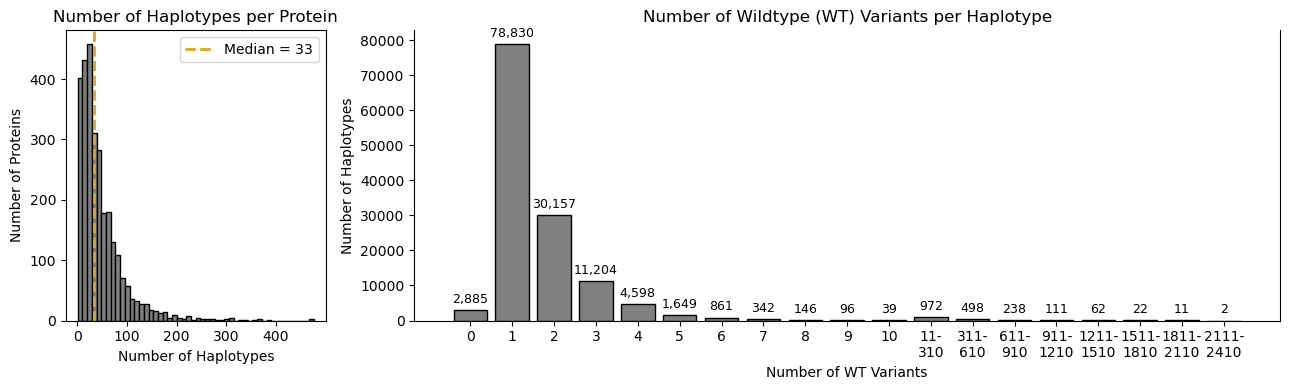

In [7]:
fig1b = hs.plot_haplotypes_summary(haplotypes)

### Figure 1C

Map haplotypes back to samples (individuals).

In [297]:
haps_to_samples = hs.haplotypes_to_samples(haplotypes=haplotypes,  
                                           as_df=True,
                                           add_sample_metadata=True,
                                           return_seqs=False, 
                                           add_ref=False, 
                                           duplicate_ref=False,
                                           verbose=True,
                                           )
haps_to_samples.head()

Extracting sample IDs:   0%|          | 0/2847 [00:00<?, ?it/s]

Number of samples: 3938
Number of transcripts to process: 2847


Processing sample to haplotype name maps:   0%|          | 0/2847 [00:00<?, ?it/s]

Converting haplotypes to DataFrame
Adding sample metadata to the DataFrame
0 samples are missing superpopulation metadata
Samples before merging: 3826
Samples after merging: 3826
Final shape: (19262867, 16)
>> haplotype(s): 132721
>> cohort(s): 3
>> cohort_sample(s): 3938
>> sample(s): 3826
>> population(s): 158
>> superpopulation(s): 8
>> sex(s): 2


,ENST_haplosaurus,cohort_sample,haplotype,cohort,sample,ploid_count,ploid,sex,Biosample ID,Population code,population_name,superpopulation,superpopulation_name,population,Data collections,population_code
0,ENST00000001146,GGVP:SC_GMJOL5309951,ENSP00000001146:264L>S,GGVP,SC_GMJOL5309951,2,0,male,NaN,GWJ,Gambian Jola,AFR,African Ancestry,GWJ,"Gambian Genome Variation Project (GRCh37),Gamb...",NaN
1,ENST00000001146,GGVP:SC_GMJOL5309951,ENSP00000001146:264L>S,GGVP,SC_GMJOL5309951,2,1,male,NaN,GWJ,Gambian Jola,AFR,African Ancestry,GWJ,"Gambian Genome Variation Project (GRCh37),Gamb...",NaN
2,ENST00000001146,1000GENOMES:phase_3:HG02151,ENSP00000001146:REF,1000GENOMES,HG02151,2,0,female,SAME1839403,CDX,Dai Chinese,EAS,East Asian Ancestry,CDX,"1000 Genomes on GRCh38,1000 Genomes 30x on GRC...",NaN
3,ENST00000001146,1000GENOMES:phase_3:HG02151,ENSP00000001146:REF,1000GENOMES,HG02151,2,1,female,SAME1839403,CDX,Dai Chinese,EAS,East Asian Ancestry,CDX,"1000 Genomes on GRCh38,1000 Genomes 30x on GRC...",NaN
4,ENST00000001146,GGVP:SC_GMWOF5428867,ENSP00000001146:REF,GGVP,SC_GMWOF5428867,2,0,female,NaN,GWW,Gambian Wolof,AFR,African Ancestry,GWW,"Gambian Genome Variation Project (GRCh37),Gamb...",NaN


In [298]:
freq_df = hs.calculate_haplotype_frequency_per_superpop(
    haps_to_samples,
    cast=True, 
    verbose=True,
    add_specificity_cols=True
) 
freq_df.head()

0 samples are missing superpopulation metadata

Number of variants specific to each superpopulation:
specific_superpopulation
AFR    35540
EAS    22458
EUR    14917
SAS    13574
AMR     9224
CSA     5134
MID     4439
OCE     1850
Name: count, dtype: int64

Percentage of superpopulation-specific haplotypes: 80.72%


,haplotype,AFR_freq,AMR_freq,CSA_freq,EAS_freq,EUR_freq,MID_freq,OCE_freq,SAS_freq,AFR_samples,AMR_samples,CSA_samples,EAS_samples,EUR_samples,MID_samples,OCE_samples,SAS_samples,top_superpopulation,top_superpopulation_freq,superpopulation_count,specific_superpopulation,specific_superpopulation_samples
0,ENSP00000001146:110H>Y,1.712292e-07,0.0,0.0,0.000000e+00,0.0,0.000000,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,AFR,1.712292e-07,1,AFR,1.0
1,"ENSP00000001146:119R>H,264L>S",2.054751e-06,0.0,0.0,0.000000e+00,0.0,0.000000,0.0,0.0,12.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,AFR,2.054751e-06,1,AFR,12.0
2,ENSP00000001146:123M>V,0.000000e+00,0.0,0.0,0.000000e+00,0.0,0.000001,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,MID,1.240141e-06,1,MID,1.0
3,"ENSP00000001146:140N>I,380E>K",0.000000e+00,0.0,0.0,2.738582e-07,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,EAS,2.738582e-07,1,EAS,1.0
4,ENSP00000001146:143K>R,1.712292e-07,0.0,0.0,0.000000e+00,0.0,0.000000,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,AFR,1.712292e-07,1,AFR,1.0


Extracting sample IDs:   0%|          | 0/2847 [00:00<?, ?it/s]

0 samples are missing superpopulation metadata


/home/schilder/projects/VEP_protein/src/haplosaurus.py:3279: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  samples = get_haplotype_samples(haplotypes, unnest=True, remove_prefix=True)


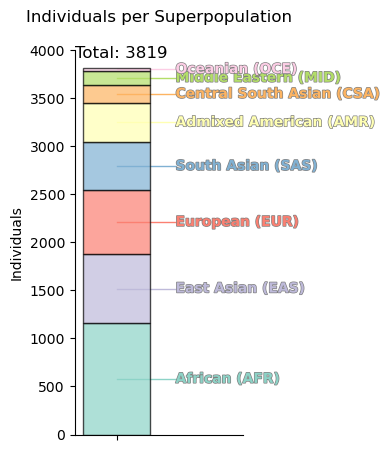

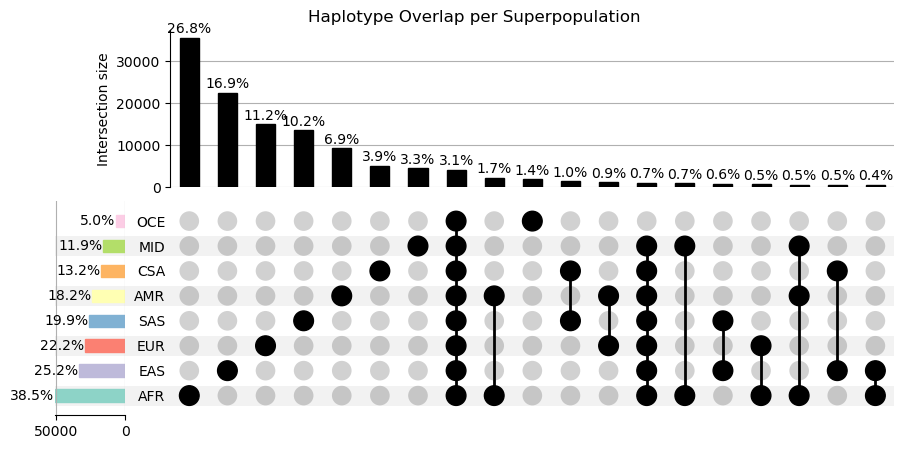

In [10]:
fig1c = hs.plot_haplotypes_and_superpop_bar(freq_df,
                                            haplotypes,
                                            width_ratios=(.2,1), figsize=(13,5))

### Figure 1D

In [3]:
vep_files = va.list_vep_files(as_df=True)

No save_dir provided, using: /home/schilder/projects/data/1KG/vep


Finding VEP files:   0%|          | 0/1 [00:00<?, ?it/s]

TypeError: join() argument must be str, bytes, or os.PathLike object, not 'list'

In [ ]:
# Focus on one model for the main plots
model_name = "esm2_t33_650M_UR50D"

force = False
tmp_vep_path = f"./results/data/vep_df_{model_name}.parquet"
if os.path.exists(tmp_vep_path) and not force:
    print(f"Loading {tmp_vep_path}")
    vep_df = pd.read_parquet(tmp_vep_path)
else:
    vep_df = va.merge_vep(add_metadata=True, 
                          scoring_strategy=["masked-marginals"], 
                          vep_files=vep_files.loc[vep_files['model_location']==model_name]
                               )
    print(f"Saving {tmp_vep_path}")
    vep_df.to_parquet(tmp_vep_path)

vep_df.head() 

Loading ./results/data/vep_df_esm2_t33_650M_UR50D.parquet


,haplotype,protein,protein_sequence,mutant,mutated_sequence,DMS_bin_score,VEP,scoring_strategy,is_ref,model_location,variant_set,ENSP,ENST,mutant_in_haplotype,site,#CHROM,POS,ID,REF,ALT,QUAL,FILTER,#Uploaded_variation,Location,Allele,Gene,Feature,Feature_type,Consequence,cDNA_position,CDS_position,Protein_position,Amino_acids,Codons,Existing_variation,IMPACT,DISTANCE,STRAND,FLAGS,REFSEQ_MATCH,REFSEQ_OFFSET,GIVEN_REF,USED_REF,BAM_EDIT,HGVSc,HGVSp,HGVS_OFFSET,AF_ESP,AF_EXAC,ALLELEID,CLNDISDB,CLNDN,CLNHGVS,CLNREVSTAT,CLNSIG,CLNSIGCONF,CLNVC,CLNVCSO,GENEINFO,MC,ORIGIN,RS,AF_TGP,CLNVI,CLNDISDBINCL,CLNDNINCL,CLNSIGINCL,EVH_epistatic,EVH_independent,ESM1V_ensemble_mean,Tranception,model_count,clinsig
0,ENSP00000262186:1032R>Q,NP_000229.1,MPVRRGHVAPQNTFLDTIIRKFEGQSRKFIIANARVENCAVIYCND...,L1045F,MPVRRGHVAPQNTFLDTIIRKFEGQSRKFIIANARVENCAVIYCND...,Benign,-3.635069,masked-marginals,False,esm2_t33_650M_UR50D,clinical_ProteinGym_substitutions,ENSP00000262186,ENST00000262186,False,NP_000229.1:L1045F,7,150947347,67473,G,A,.,PASS,67473,7:150947347,A,3757,NM_000238.4,Transcript,missense_variant,3541,3133,1045,L/F,Ctc/Ttc,-,MODERATE,-,-1,-,-,-,G,G,-,NM_000238.4:c.3133C>T,NP_000229.1:p.Leu1045Phe,-,NaN,0.00000,78369,"MedGen:CN230736|EFO:EFO_0004269,Human_Phenotyp...",Cardiovascular_phenotype|Cardiac_arrhythmia|Co...,NC_000007.14:g.150947347G>A,"criteria_provided,_multiple_submitters,_no_con...",Benign,NaN,single_nucleotide_variant,SO:0001483,KCNH2:3757,SO:0001583|missense_variant,1,199473025,NaN,ClinGen:CA008015,None,None,None,NaN,NaN,-6.731237,-0.021689,6,benign
1,ENSP00000262186:1032R>Q,NP_000229.1,MPVRRGHVAPQNTFLDTIIRKFEGQSRKFIIANARVENCAVIYCND...,D1003Y,MPVRRGHVAPQNTFLDTIIRKFEGQSRKFIIANARVENCAVIYCND...,Pathogenic,-1.670645,masked-marginals,False,esm2_t33_650M_UR50D,clinical_ProteinGym_substitutions,ENSP00000262186,ENST00000262186,False,NP_000229.1:D1003Y,7,150947473,200516,C,A,.,PASS,200516,7:150947473,A,3757,NM_000238.4,Transcript,missense_variant,3415,3007,1003,D/Y,Gac/Tac,-,MODERATE,-,-1,-,-,-,C,C,-,NM_000238.4:c.3007G>T,NP_000229.1:p.Asp1003Tyr,-,NaN,NaN,197155,MedGen:CN517202,not_provided,NC_000007.14:g.150947473C>A,"criteria_provided,_single_submitter",Likely_pathogenic,NaN,single_nucleotide_variant,SO:0001483,KCNH2:3757,"SO:0001583|missense_variant,SO:0001619|non-cod...",1,794728402,NaN,ClinGen:CA007791,None,None,None,NaN,NaN,-2.509515,-0.039753,6,likely_path
2,ENSP00000262186:1032R>Q,NP_000229.1,MPVRRGHVAPQNTFLDTIIRKFEGQSRKFIIANARVENCAVIYCND...,N996I,MPVRRGHVAPQNTFLDTIIRKFEGQSRKFIIANARVENCAVIYCND...,Pathogenic,-4.619007,masked-marginals,False,esm2_t33_650M_UR50D,clinical_ProteinGym_substitutions,ENSP00000262186,ENST00000262186,False,NP_000229.1:N996I,7,150947493,67458,T,A,.,PASS,67458,7:150947493,A,3757,NM_000238.4,Transcript,missense_variant,3395,2987,996,N/I,aAc/aTc,-,MODERATE,-,-1,-,-,-,T,T,-,NM_000238.4:c.2987A>T,NP_000229.1:p.Asn996Ile,-,NaN,NaN,78354,"MONDO:MONDO:0019171,MedGen:C1141890,OMIM:PS192...",Congenital_long_QT_syndrome|not_provided|Long_...,NC_000007.14:g.150947493T>A,"criteria_provided,_multiple_submitters,_no_con...",Pathogenic/Likely_pathogenic,NaN,single_nucleotide_variant,SO:0001483,KCNH2:3757,"SO:0001583|missense_variant,SO:0001619|non-cod...",1,199473018,NaN,ClinGen:CA007728|UniProtKB:Q12809#VAR_068285,None,None,None,NaN,NaN,-5.869637,-0.057342,6,likely_path
3,ENSP00000262186:1032R>Q,NP_000229.1,MPVRRGHVAPQNTFLDTIIRKFEGQSRKFIIANARVENCAVIYCND...,E978K,MPVRRGHVAPQNTFLDTIIRKFEGQSRKFIIANARVENCAVIYCND...,Benign,-0.514701,masked-marginals,False,esm2_t33_650M_UR50D,clinical_ProteinGym_substitutions,ENSP00000262186,ENST00000262186,False,NP_000229.1:E978K,7,150947639,67453,C,T,.,PASS,67453,7:150947639,T,3757,NM_000238.4,Transcript,missense_variant,3340,2932,978,E/K,Gag/Aag,-,MODERATE,-,-1,-,-,-,C,C,-,NM_000238.4:c.2932G>A,NP_000229.1:p.Glu978Lys,-,0.00008,0.00039,78349,"EFO:EFO_0004269,Human_Phenotype_Ontology:HP:00...",Cardiac_arrhythmia|Cardiovascular_phenotype|no...,NC_000007.14:g.150947639C>T,"criteria_provided,_multip

  0%|          | 0/2525 [00:00<?, ?it/s]

Extracting ID columns.
Using default maps.
Simplifying annotations.
      ClinSig  Count       Source Consequence    Consequence (Source)
0      benign   2615  SpliceVarDB    Splicing  Splicing (SpliceVarDB)
1  pathogenic   3327  SpliceVarDB    Splicing  Splicing (SpliceVarDB)
0      benign  11718      ClinVar         UTR           UTR (ClinVar)
1  pathogenic   2053      ClinVar         UTR           UTR (ClinVar)
0      benign  30727   ProteinGym    Missense   Missense (ProteinGym)
1  pathogenic  32000   ProteinGym    Missense   Missense (ProteinGym)


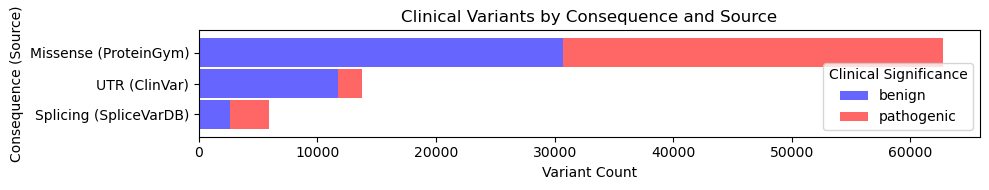

In [7]:
fig1d = va.variant_count_by_source_barplot(show_plot=True)

### Figure 1E

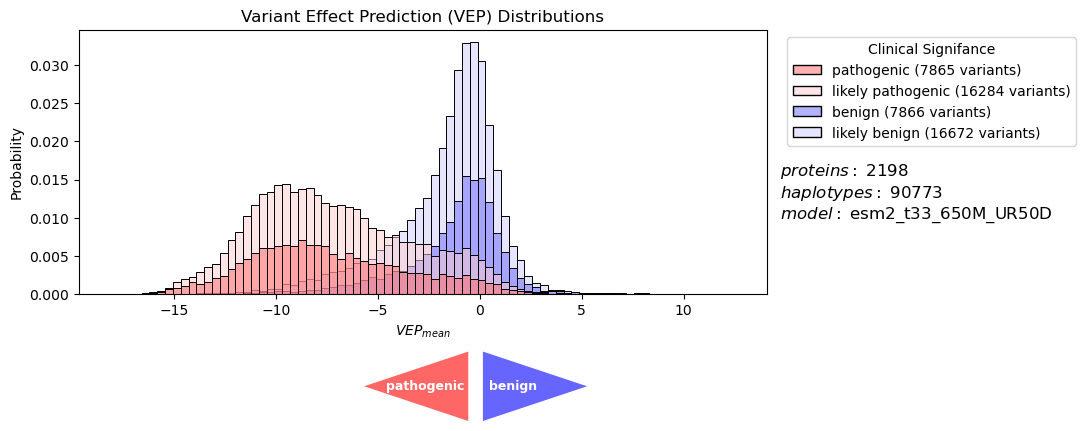

In [119]:
fig1e = db.plot_vep_histogram_with_arrows(vep_df, model_name=model_name,  
                                          arrow_y= -0.35,
                                          arrow_head_length=0.047,
                                          arrow_length=.19,
                                          figsize=(11, 4),
                                          arrow_text_fontsize=9,
                                          external_legend_annotation=True)

### Figure 1F

<string>:85: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

<string>:149: UserWarning:

This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.



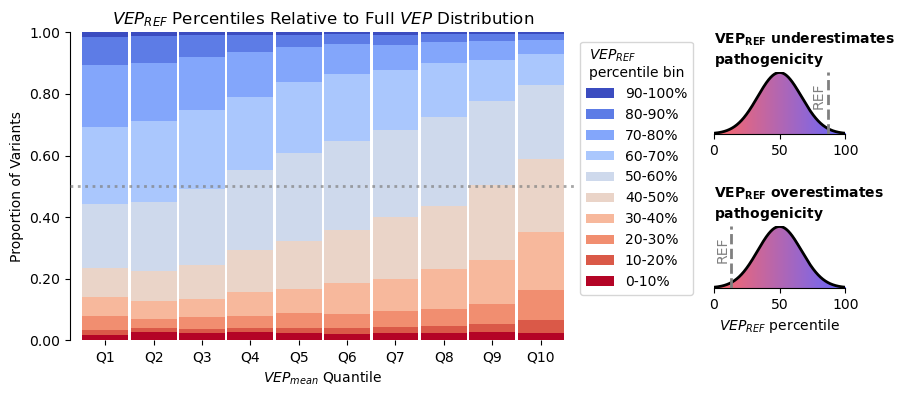

In [262]:
#### Percentile barplot version #### 
fig1f_pct = db.plot_ref_vep_percentile_stacked_bar(vep_df,
                                                    figsize=(10, 4), 
                                                    barplot_width_ratio=5,
                                                    legend_on_right=True,
                                                    show_schematic_xlabel=(False, True), 
                                                    show_schematic_ylabel=[False, False],
                                                    show_vertical_arrows=False,  
                                                    legend_height_factor=1.5,
                                                        schematic_width_ratio=1.3,
                                                        schematic_padding_left=0.12,
                                                        schematic_padding_top=0.1,
                                                    schematic_heights=[0.2, 0.3, 0.2]
                                                    )

In [ ]:
# For each group, get the "VEP" value for the row where is_ref==True
groupby_cols = ['model_location','protein','clinsig','mutant','scoring_strategy']
ref_vep = vep_df.loc[vep_df["is_ref"]].set_index(groupby_cols)["VEP"]
vep_df["VEP_REF"] = vep_df.set_index(groupby_cols).index.map(ref_vep)
vep_df["VEP_ref_diff"] = vep_df["VEP_REF"] - vep_df["VEP"]

In [ ]:
# For each group, get the "VEP" value for the row where is_ref==True
groupby_cols = ['model_location','protein','clinsig','mutant','scoring_strategy']
ref_vep = vep_df.loc[vep_df["is_ref"]].set_index(groupby_cols)["VEP"]
vep_df["VEP_REF"] = vep_df.set_index(groupby_cols).index.map(ref_vep)
vep_df["VEP_ref_diff"] = vep_df["VEP_REF"] - vep_df["VEP"]

## Figure 2

In [2]:
uniprot_ids = {"BRCA1":"P38398", 
               "DYPD":"Q12882"}
tx_ids = {"BRCA1":"ENST00000357654", 
          "DYPD":""}
refseq_ids = {"BRCA1": 'NP_009225.1',
              "DYPD": 'NP_000101.2'}

# Get specific instance of the protein
target_gene = "BRCA1" # DYPD
uniprot_id = uniprot_ids[target_gene]
refseq_id = refseq_ids[target_gene]
tx_id = tx_ids[target_gene] 

In [100]:

#### Import directly from AlphaFoldDB ####
# structure = cf.import_mmcif(protein_id = uniprot_id)[0]
# contact_map = cf.get_contact_map(structure, 
#                                  max_distance=8.0, 
#                                  continuous=True, 
#                                  return_distance_map=True )


#### Import from local AlphaFold files that I generated myself ####
pdb_files = cf.search_files(base_dir =  os.path.expanduser("~/projects/data/colabfold"),
                            tx_id = tx_id,
                            subdir = "af2_sameMSA",
                            suffix = ".pdb*",
                            model_number = 1,
                            ref_only = True) 

contact_map_ref = cf.import_contact_maps(pdb_files,
                                        return_distance_map=True,
                                        continuous=True,
                                        as_dict=False)  


contact_map_dist_ref = cf.import_contact_maps(pdb_files,
                                            return_raw_distance_map=True,
                                            as_dict=False)  


1 PDB files found


100%|██████████| 1/1 [00:00<00:00,  2.89it/s]


Contact enrichment for BRCA1 WT vs. Clinical variant interactions.

In [4]:
contact_map_binary_ref = cf.import_contact_maps(pdb_files,
                                                max_distance=8.0, 
                                                continuous=False, 
                                                return_distance_map=False,
                                                as_dict=False ) 

100%|██████████| 1/1 [00:01<00:00,  1.45s/it]


In [5]:
model_name = "esm2_t33_650M_UR50D"

if 'vep_files' not in globals():
    vep_files = va.list_vep_files(model_location=model_name, 
                                  as_df=True)

vep_prot = va.merge_vep(
    scoring_strategy=["masked-marginals"],
    vep_files=vep_files.loc[(vep_files['model_location']==model_name) & 
                            (vep_files['protein']==refseq_id)]
    )
print("n_haplotypes: ", vep_prot["haplotype"].nunique())
vep_prot["HGNC"] = vep_prot["GENEINFO"].str.split(":").str[0]  


No save_dir provided, using: /home/schilder/projects/data/1KG/vep


Finding VEP files:   0%|          | 0/1 [00:00<?, ?it/s]

Found 894174 parquet files in /home/schilder/projects/data/1KG/vep
Unique values:
>> model_location: 8
scoring_strategy: 3
variant_set: 1
haplotype: 111422
protein: 2251
No save_dir provided, using: /home/schilder/projects/data/1KG/vep
Found 144 masked-marginals parquet files


Reading files:   0%|          | 0/144 [00:00<?, ?it/s]

Concatenating VEP dataframes
Loading ==> /home/schilder/projects/data/haplosaurus/tx_id_map.pkl


Loading '/home/schilder/projects/data/haplosaurus/tx_id_map.pkl': 100%|██████████| 1.70M/1.70M [00:00<00:00, 748MB/s]


VEP dataframe shape: (65664, 73)
n_haplotypes:  144


Use ridge regression to find WT-Clinical variant interactions.

In [6]:
wtvariants_to_vep_linear_model_out = ab.wtvariants_to_vep_linear_model(vep_df=vep_prot,
                                                                       alpha=1)  
ridge_df = wtvariants_to_vep_linear_model_out["interaction_df"]

vep_matrix shape:  (144, 456)
wt_matrix shape:  (144, 132)
Dropped 1 haplotypes due to NaNs in input or target matrices.


<Axes: xlabel='position_distance', ylabel='Count'>

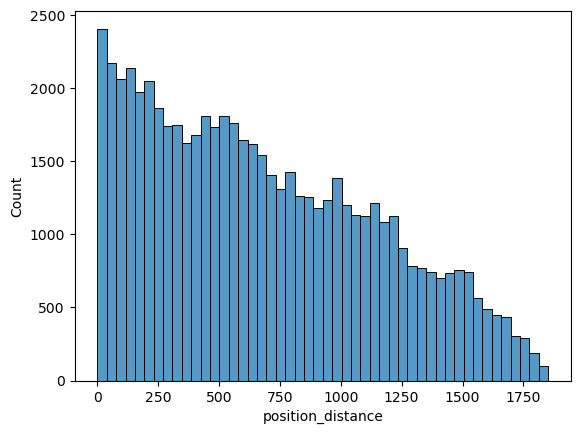

In [15]:
ridge_df["position_distance"] = (ridge_df["wt_position"] - ridge_df["clinical_position"]).abs()
sns.histplot(ridge_df, x="position_distance")

In [108]:
def safe_int(val):
    try:
        if pd.isna(val):
            return None
        return int(val)
    except Exception:
        return None

def get_contact_score(x, contact_map):
    wt_pos = safe_int(x["wt_position"])
    clin_pos = safe_int(x["clinical_position"])
    if wt_pos is None or clin_pos is None:
        return np.nan
    return contact_map[wt_pos-1, clin_pos-1]

# Use a lambda to pass contact_map_ref as a closure variable, avoiding the error
ridge_df["Angstroms"] = ridge_df.apply(lambda x: get_contact_score(x, contact_map_dist_ref), axis=1)
ridge_df["is_contact"] = ridge_df.apply(lambda x: get_contact_score(x, contact_map_binary_ref)==1, axis=1) 
ridge_df["clinical_variant_fmt"] = ridge_df["clinical_variant"].apply(
    lambda x: (
        f"{x[1:-1]}{x[0]}>{x[-1]}"
        if isinstance(x, str) and len(x) >= 3 and x[1:-1].isdigit()
        else x
    )
)

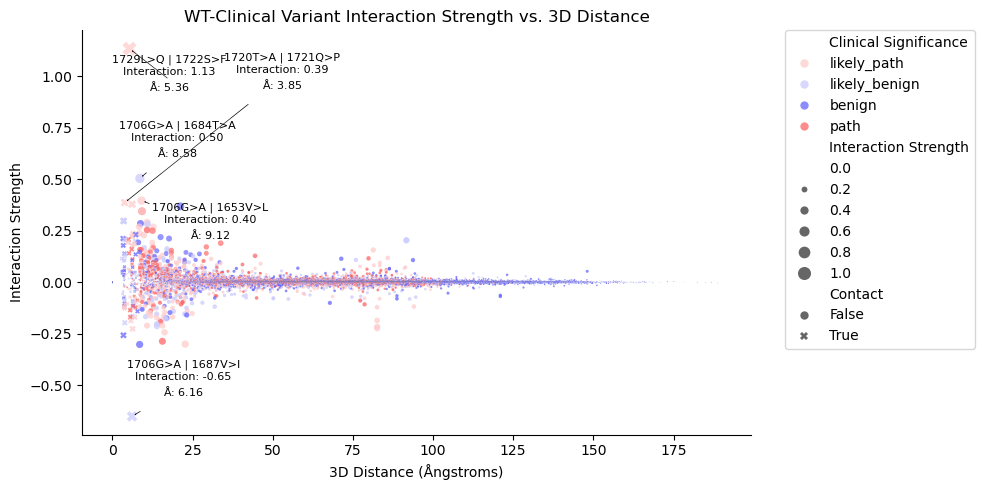

In [212]:
from adjustText import adjust_text

# Number of top interactions to label
N = 5

# Sort by absolute interaction strength and select top N
ridge_df['protein'] = ridge_df['site'].str.split(":").str[0]
ridge_df = utils.add_hgvsp_id(ridge_df)
if "clinsig" not in ridge_df.columns:
    ridge_df = ridge_df.merge(vep_prot[["mutant", "clinsig"]].drop_duplicates(), 
                            left_on="clinical_variant", 
                            right_on="mutant", 
                            how="left")

top_interactions = ridge_df.reindex(ridge_df["interaction_strength"].abs().sort_values(ascending=False).index).head(N)

ridge_df["Angstroms_inverted"] = ridge_df["Angstroms"].max() - ridge_df["Angstroms"]

# To reverse the point size scale, we need to map large Angstroms to small sizes and vice versa.
# We'll use the size_norm parameter in seaborn.scatterplot, which takes a matplotlib.colors.Normalize object.
import matplotlib as mpl

plt.figure(figsize=(10, 5))

# Set the min/max for the colormap normalization
# import matplotlib as mpl
# vmin = -2
# vmax = np.nanpercentile(ridge_df["Angstroms"], 10)  # e.g., bottom 10th percentile to avoid outliers/brightest colors
# norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)

x_var = "Angstroms"
y_var = "interaction_strength_signed"
hue_var = "clinsig"
size_var = "interaction_strength"
style_var = "is_contact"
ax = sns.scatterplot(
    data=ridge_df.sort_values(y_var, ascending=False),
    # data=  utils.sort_by_clinsig(ridge_df, ascending=False),
    x=x_var,
    y=y_var,
    hue=hue_var,
    size=size_var,
    style=style_var,
    sizes=(0.001,100),
    alpha=0.75,
    # palette="gnuplot2_r",
    palette=utils.get_clinsig_palette(),
    edgecolor="grey",
    linewidth=0.01,
    # hue_norm=norm,  # Use hue_norm instead of vmin/vmax
)

plt.xlabel("3D Distance (Ångstroms)")
plt.ylabel("Interaction Strength")
plt.title("WT-Clinical Variant Interaction Strength vs. 3D Distance")

# Move legend outside the plot (to the right)
# Change legend titles
legend = ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
for leg in legend.get_texts():
    if "contact_score" in leg.get_text().lower() or "size" in leg.get_text().lower():
        leg.set_text("Contact Score")
    if "interaction_strength" in leg.get_text().lower():
        leg.set_text("Interaction Strength")
    if "is_contact" in leg.get_text().lower():
        leg.set_text("Contact")
    if "Angstroms_inverted" in leg.get_text().lower():
        leg.set_text(r"Angstroms")
    if "clinsig" in leg.get_text().lower():
        leg.set_text("Clinical Significance")

# Prepare label texts for top N points
texts = []
for _, row in top_interactions.iterrows():
    label = f"{row['wt_variant']} | {row['clinical_variant_fmt']}\n"\
            + f"Interaction: {row['interaction_strength_signed']:.2f}\n"\
            + f"$\\mathrm{{\\AA}}$: {row['Angstroms']:.2f}\n"
            # + f"Contact: {row['is_contact']}"
    texts.append(
        plt.text(
            row[x_var],
            row[y_var],
            label,
            fontsize=8,
            # weight='bold',
            color='black',
            bbox=dict(facecolor='white', alpha=0.1, edgecolor='none', boxstyle='round,pad=0.2'),
            # ha='left'  # Left align the text
        )
    )
# Remove top and right spines (margin lines)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Adjust text to avoid overlap
adjust_text(
    texts,
    arrowprops=dict(arrowstyle='->', color='black', lw=0.5),
    ax=ax, 
    # expand_points=(100, 2), 
)

plt.tight_layout()  # To make room for the legend outside the plot
plt.show()

In [ ]:
vep_prot.loc[vep_prot["mutant"].isin(top_interactions["clinical_variant"].unique()[:1])]

,haplotype,protein,protein_sequence,mutant,mutated_sequence,DMS_bin_score,VEP,scoring_strategy,is_ref,model_location,variant_set,ENSP,ENST,mutant_in_haplotype,site,#CHROM,POS,ID,REF,ALT,QUAL,FILTER,#Uploaded_variation,Location,Allele,Gene,Feature,Feature_type,Consequence,cDNA_position,CDS_position,Protein_position,Amino_acids,Codons,Existing_variation,IMPACT,DISTANCE,STRAND,FLAGS,REFSEQ_MATCH,REFSEQ_OFFSET,GIVEN_REF,USED_REF,BAM_EDIT,HGVSc,HGVSp,HGVS_OFFSET,AF_ESP,AF_EXAC,ALLELEID,CLNDISDB,CLNDN,CLNHGVS,CLNREVSTAT,CLNSIG,CLNSIGCONF,CLNVC,CLNVCSO,GENEINFO,MC,ORIGIN,RS,AF_TGP,CLNVI,CLNDISDBINCL,CLNDNINCL,CLNSIGINCL,EVH_epistatic,EVH_independent,ESM1V_ensemble_mean,Tranception,model_count,clinsig,HGNC
81,ENSP00000350283:1028R>H,NP_009225.1,MDLSALRVEEVQNVINAMQKILECPICLELIKEPVSTKCDHIFCKF...,S1722F,MDLSALRVEEVQNVINAMQKILECPICLELIKEPVSTKCDHIFCKF...,Pathogenic,-9.090712,masked-marginals,False,esm2_t33_650M_UR50D,clinical_ProteinGym_substitutions,ENSP00000350283,ENST00000357654,False,NP_009225.1:S1722F,17,43063361,55441,G,A,.,PASS,55441,17:43063361,A,672,NM_007294.4,Transcript,missense_variant,5278,5165,1722,S/F,tCt/tTt,-,MODERATE,-,-1,-,-,-,G,G,-,NM_007294.4:c.5165C>T,NP_009225.1:p.Ser1722Phe,-,NaN,NaN,70108,"MedGen:CN169374|MONDO:MONDO:0013685,MedGen:C32...","not_specified|Pancreatic_cancer,_susceptibilit...",NC_000017.11:g.43063361G>A,"criteria_provided,_multiple_submitters,_no_con...",Pathogenic/Likely_pathogenic,NaN,single_nucleotide_variant,SO:0001483,BRCA1:672,"SO:0001583|missense_variant,SO:0001619|non-cod...",1,80357104,NaN,ClinGen:CA003318,NaN,NaN,NaN,NaN,NaN,-7.100712,NaN,6,likely_path,BRCA1
537,"ENSP00000350283:1038E>G,1613S>G",NP_009225.1,MDLSALRVEEVQNVINAMQKILECPICLELIKEPVSTKCDHIFCKF...,S1722F,MDLSALRVEEVQNVINAMQKILECPICLELIKEPVSTKCDHIFCKF...,Pathogenic,-9.099968,masked-marginals,False,esm2_t33_650M_UR50D,clinical_ProteinGym_substitutions,ENSP00000350283,ENST00000357654,False,NP_009225.1:S1722F,17,43063361,55441,G,A,.,PASS,55441,17:43063361,A,672,NM_007294.4,Transcript,missense_variant,5278,5165,1722,S/F,tCt/tTt,-,MODERATE,-,-1,-,-,-,G,G,-,NM_007294.4:c.5165C>T,NP_009225.1:p.Ser1722Phe,-,NaN,NaN,70108,"MedGen:CN169374|MONDO:MONDO:0013685,MedGen:C32...","not_specified|Pancreatic_cancer,_susceptibilit...",NC_000017.11:g.43063361G>A,"criteria_provided,_multiple_submitters,_no_con...",Pathogenic/Likely_pathogenic,NaN,single_nucleotide_variant,SO:0001483,BRCA1:672,"SO:0001583|missense_variant,SO:0001619|non-cod...",1,80357104,NaN,ClinGen:CA003318,NaN,NaN,NaN,NaN,NaN,-7.100712,NaN,6,likely_path,BRCA1
993,ENSP00000350283:1040S>N,NP_009225.1,MDLSALRVEEVQNVINAMQKILECPICLELIKEPVSTKCDHIFCKF...,S1722F,MDLSALRVEEVQNVINAMQKILECPICLELIKEPVSTKCDHIFCKF...,Pathogenic,-9.103022,masked-marginals,False,esm2_t33_650M_UR50D,clinical_ProteinGym_substitutions,ENSP00000350283,ENST00000357654,False,NP_009225.1:S1722F,17,43063361,55441,G,A,.,PASS,55441,17:43063361,A,672,NM_007294.4,Transcript,missense_variant,5278,5165,1722,S/F,tCt/tTt,-,MODERATE,-,-1,-,-,-,G,G,-,NM_007294.4:c.5165C>T,NP_009225.1:p.Ser1722Phe,-,NaN,NaN,70108,"MedGen:CN169374|MONDO:MONDO:0013685,MedGen:C32...","not_specified|Pancreatic_cancer,_susceptibilit...",NC_000017.11:g.43063361G>A,"criteria_provided,_multiple_submitters,_no_con...",Pathogenic/Likely_pathogenic,NaN,single_nucleotide_variant,SO:0001483,BRCA1:672,"SO:0001583|missense_variant,SO:0001619|non-cod...",1,80357104,NaN,ClinGen:CA003318,NaN,NaN,NaN,NaN,NaN,-7.100712,NaN,6,likely_path,BRCA1
1449,ENSP00000350283:1099P>L,NP_009225.1,MDLSALRVEEVQNVINAMQKILECPICLELIKEPVSTKCDHIFCKF...,S1722F,MDLSALRVEEVQNVINAMQKILECPICLELIKEPVSTKCDHIFCKF...,Pathogenic,-9.112766,masked-marginals,False,esm2_t33_650M_UR50D,clinical_ProteinGym_substitutions,ENSP00000350283,ENST00000357654,False,NP_009225.1:S1722F,17,43063361,55441,G,A,.,PASS,55441,17:43063361,A,672,NM_007294.4,Transcript,missense_variant,5278,5165,1722,S/F,tCt/tTt,-,MODERATE,-,-1,-,-,-,G,G,-,NM_007294.4:c.5165C>T,NP_009225.1:p.Ser1722Phe,-,NaN,NaN,70108,"MedGen:CN169374|MONDO:MOND

In [99]:
# import plotly.express as px
# import numpy as np

# # To apply a log transform to the color bar, we need to create a new column with the log-transformed values.
# # We'll use np.sign(x) * log1p(abs(x)) to preserve sign and handle zero/negative values.
# ridge_df["_log_interaction_strength_signed"] = np.sign(ridge_df["interaction_strength_signed"]) * np.log1p(np.abs(ridge_df["interaction_strength_signed"]))
# ridge_df["_log_interaction_strength"] = np.log1p(np.abs(ridge_df["interaction_strength"]))

# fig = px.scatter(
#     ridge_df,
#     x="position_distance",
#     y="interaction_strength",
#     color="_log_interaction_strength", 
#     size="interaction_strength",
#     hover_data=["wt_variant", "site", "clinical_position", "wt_position", "interaction_strength_signed"], 
#     width=1000,
#     height=500, 
#     template="simple_white",  # set background to white
#     title="Interaction Strength vs. Position Distance (log color scale)", 
#     color_continuous_scale="Viridis",
#     labels={"_log_interaction_strength": "log1p(|interaction_strength|)"},
# )
# fig.show()

### Figure 2A

Toy schematic of variant sensitization maps methodology (ridge regression method).

In [294]:
def select_dense_high_variance_submatrix(
    Xwt, 
    top_n_cols=20, 
    top_n_rows=10, 
    remove_high_density=True, 
    density_threshold=0.9, 
    display_result=True
):
    """
    Selects a submatrix of Xwt with the densest and most variable rows/columns of 1s.

    Returns:
        filtered_submatrix: pd.DataFrame
            The selected submatrix after all filtering.
        top10_rows: pd.Index
            Index of selected rows before density filtering.
        top10_cols: pd.Index
            Index of selected columns before density filtering.
    """
    # 1. Find up to top_n_cols columns with the most 1s overall (to allow for variance filtering)
    col_ones = Xwt.sum(axis=0)
    top_cols_candidates = col_ones.sort_values(ascending=False).index[:top_n_cols]

    # 2. Compute variance for these columns, and select the top_n_cols with highest variance
    col_variance = Xwt[top_cols_candidates].var(axis=0)
    top10_cols = col_variance.sort_values(ascending=False).index[:top_n_cols]

    # 3. For these columns, compute row-wise density of 1s
    submatrix = Xwt.loc[:, top10_cols]
    row_density = submatrix.sum(axis=1) / len(top10_cols)

    # 4. Among all rows, select up to top_n_rows with highest density (to allow for variance filtering)
    top_rows_candidates = row_density.sort_values(ascending=False).index[:top_n_rows]

    # 5. Compute variance for these rows, and select the top_n_rows with highest variance
    row_variance = submatrix.loc[top_rows_candidates].var(axis=1)
    top10_rows = row_variance.sort_values(ascending=False).index[:top_n_rows]

    # 6. Show the submatrix of these rows/columns
    top10_submatrix = Xwt.loc[top10_rows, top10_cols]

    if remove_high_density:
        # 7. Remove columns or rows that are >=density_threshold 1s in the submatrix
        col_1_density = top10_submatrix.sum(axis=0) / top10_submatrix.shape[0]
        row_1_density = top10_submatrix.sum(axis=1) / top10_submatrix.shape[1]
        cols_to_keep = col_1_density < density_threshold
        rows_to_keep = row_1_density < density_threshold
        # Fix: .loc expects index/column labels, not boolean arrays with different index
        filtered_submatrix = top10_submatrix.loc[
            top10_submatrix.index[rows_to_keep.values], 
            top10_submatrix.columns[cols_to_keep.values]
        ]
    else:
        filtered_submatrix = top10_submatrix

    if display_result:
        print(f"Selected columns (up to {top_n_cols} with most 1s and highest variance):", 
              list(top10_cols[top10_submatrix.columns.get_indexer(filtered_submatrix.columns)]))
        print(f"Top {top_n_rows} rows with highest density and variance of 1s in these columns:", 
              list(top10_rows[top10_submatrix.index.get_indexer(filtered_submatrix.index)]))
        print(f"Submatrix (top {top_n_rows} rows x selected columns), after removing rows/cols >= {density_threshold*100:.0f}% 1s:" if remove_high_density else
              f"Submatrix (top {top_n_rows} rows x selected columns), no density filtering:")
        display(filtered_submatrix)
    return filtered_submatrix, top10_rows, top10_cols

# Example usage:
filtered_submatrix, top10_rows, top10_cols = select_dense_high_variance_submatrix(Xwt)


Selected columns (up to 20 with most 1s and highest variance): ['693D>N', '356Q>R', '820K>E', '723N>D', '1140S>G', '841R>W', '1040S>N', '925I>L', '1200Q>H', '1804V>D', '1628M>T', '762R>S', '1561T>I', '308S>T', '246L>V', '1652M>I']
Top 10 rows with highest density and variance of 1s in these columns: ['ENSP00000350283:693D>N,762R>S,871P>L,1038E>G,1183K>R,1613S>G', 'ENSP00000350283:693D>N,871P>L,1038E>G,1183K>R,1613S>G,1804V>D', 'ENSP00000350283:693D>N,871P>L,1038E>G,1140S>G,1183K>R,1613S>G', 'ENSP00000350283:693D>N,871P>L,1038E>G,1183K>R,1613S>G', 'ENSP00000350283:693D>N,871P>L,1038E>G,1183K>R,1468N>D,1613S>G', 'ENSP00000350283:762R>S,871P>L,1038E>G,1183K>R,1613S>G', 'ENSP00000350283:693D>N,866R>C,871P>L,1038E>G,1183K>R,1613S>G', 'ENSP00000350283:871P>L,925I>L,1038E>G,1183K>R,1613S>G', 'ENSP00000350283:723N>D,871P>L,1183K>R,1561T>I,1613S>G', 'ENSP00000350283:693D>N,871P>L,1038E>G,1183K>R,1613S>G,1771P>A']
Submatrix (top 10 rows x selected columns), after removing rows/cols >= 90% 1s:


wt_variant,693D>N,356Q>R,820K>E,723N>D,1140S>G,841R>W,1040S>N,925I>L,1200Q>H,1804V>D,1628M>T,762R>S,1561T>I,308S>T,246L>V,1652M>I
haplotype,,,,,,,,,,,,,,,,
"ENSP00000350283:693D>N,762R>S,871P>L,1038E>G,1183K>R,1613S>G",1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0
"ENSP00000350283:693D>N,871P>L,1038E>G,1183K>R,1613S>G,1804V>D",1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0
"ENSP00000350283:693D>N,871P>L,1038E>G,1140S>G,1183K>R,1613S>G",1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0
"ENSP00000350283:693D>N,871P>L,1038E>G,1183K>R,1613S>G",1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
"ENSP00000350283:693D>N,871P>L,1038E>G,1183K>R,1468N>D,1613S>G",1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
"ENSP00000350283:762R>S,871P>L,1038E>G,1183K>R,1613S>G",0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0
"ENSP00000350283:693D>N,866R>C,871P>L,1038E>G,1183K>R,1613S>G",1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
"ENSP00000350283:871P>L,925I>L,1038E>G,1183K>R,1613S>G",0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0
"ENSP00000350283:723N>D,871P>L,1183K>R,1561T>I,1613S>G",0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0


In [367]:
n_clinical_variants = 10
interaction_df = wtvariants_to_vep_linear_model_out['interaction_df']
Xvep = wtvariants_to_vep_linear_model_out['y_vep_clean'].copy()


# Sort interaction_df by 'clinical_position'
interaction_df_sorted = interaction_df.sort_values('clinical_position')
# Take the top N clinical variants from the 'clinical_variant' column
selected_clinical_variants = interaction_df_sorted['site'].unique().tolist()[:n_clinical_variants]
selected_clinical_variants
# Xvep = Xvep.loc[haplotypes_to_plot].loc[:, selected_clinical_variants].round(1)

['NP_009225.1:L6R',
 'NP_009225.1:R7L',
 'NP_009225.1:M18R',
 'NP_009225.1:M18T',
 'NP_009225.1:M18K',
 'NP_009225.1:L22S',
 'NP_009225.1:C24W',
 'NP_009225.1:C24G',
 'NP_009225.1:C24R',
 'NP_009225.1:C24S']

/home/schilder/.conda/envs/esm2/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning:

Clustering large matrix with scipy. Installing `fastcluster` may give better performance.

/home/schilder/.conda/envs/esm2/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning:

Clustering large matrix with scipy. Installing `fastcluster` may give better performance.



Found 10x10 submatrix at rows 0-10, cols 121-131 with 20.0% 1s


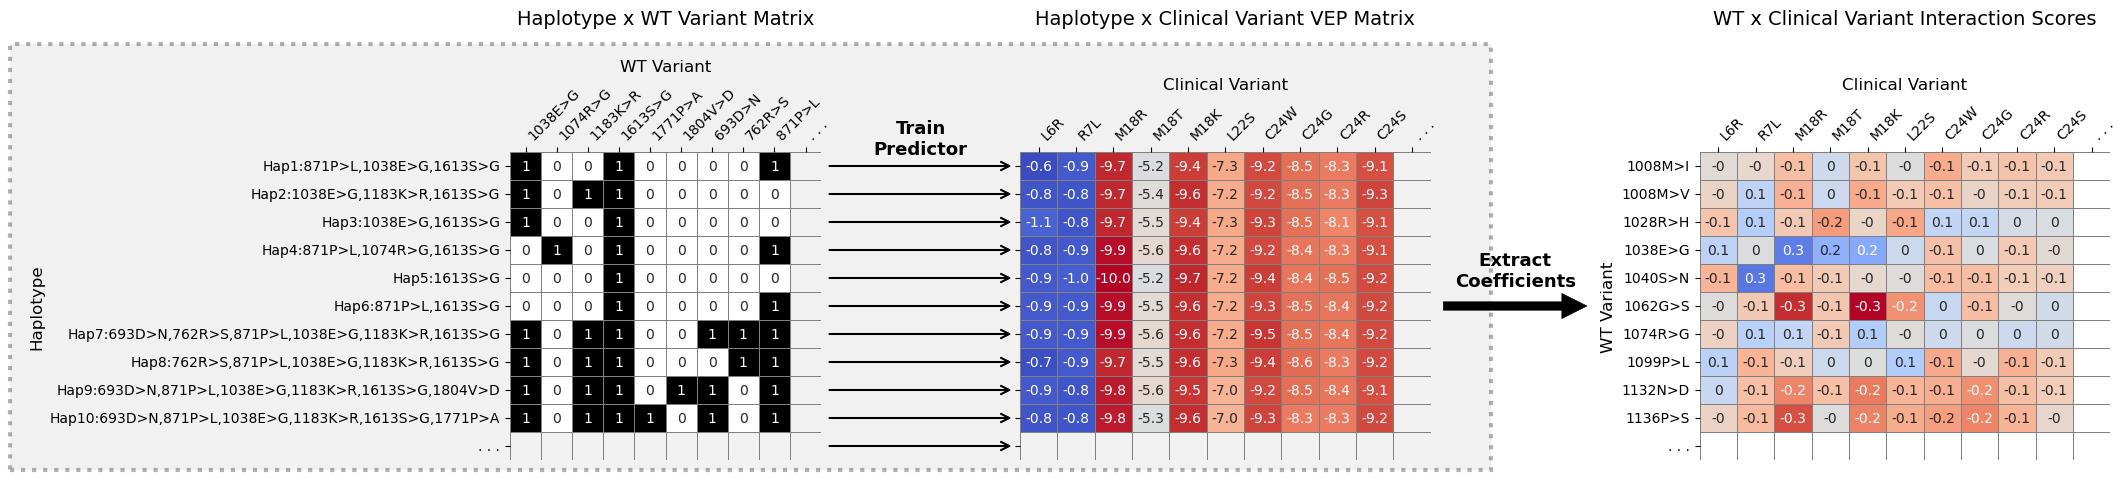

<Figure size 640x480 with 0 Axes>

In [385]:
fig2a = ab.plot_variant_sensitization_schematic(wtvariants_to_vep_linear_model_out,    
                                                n_clinical_variants=10,
                                                n_haplotypes=10,
                                                n_wt_variants=10,
                                                title_y_position=1.2,
                                                include_any_1_col=True, 
                                                include_any_1_row=False,
                                                grey_box_left_extension=0.23, 
                                                grey_box_top_extension=0.25, 
                                                add_grey_box=True,   
                                                rotate_x_labels=True, 
                                                heatmap_aspect=(.9, .75, .75),
                                                replace_haplotype_prefix=True)
fig2a['fig']

### Figure 2B

BRCA1 AlphaFold contact map (reference sequence).

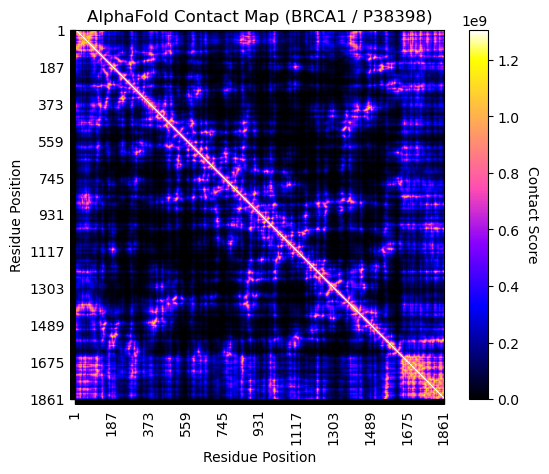

In [39]:
contact_map_ref, contact_map_ref_binned = cf.plot_contact_map(contact_map=contact_map_ref, 
                                                                title=f"AlphaFold Contact Map ({target_gene} / {uniprot_id})",  
                                                                bin_size=1,   
                                                                pow=4, 
                                                                agg_func=np.nanmax)

### Figure 2C

BRCA1 sensitization map (aligned) +  BRCA1 AlphaFold contact map (reference sequence).

Choose a threshold for the interaction strength and compute the contact enrichment at that specific threshold.  
Then plot the contact map and the sensitization map.

In [41]:
interaction_threshold = 0.05

top_interactions = ridge_df.loc[ridge_df["interaction_strength"] > interaction_threshold]    

ridge_enrichment_at_threshold = ab.compute_enrichment_vs_threshold(
    outlier_df=ridge_df,
    contact_map_binary=contact_map_binary_ref, 
    thresholds=[interaction_threshold],
    linear_sampling=False,  
    interaction_col="interaction_strength"
)

print()
print(f"Number of top interactions: {top_interactions.shape[0]}" + \
      f" ({top_interactions.shape[0] / ridge_df.shape[0]*100:.2f}% of all WT-Clinical variant pairs)")
print(f"Enrichment at threshold {interaction_threshold}: {ridge_enrichment_at_threshold['enrichment'].values[0]:.2f}x" )

  0%|          | 0/1 [00:00<?, ?it/s]

100%|██████████| 1/1 [00:00<00:00, 22.88it/s]


Number of top interactions: 518 (0.86% of all WT-Clinical variant pairs)
Enrichment at threshold 0.05: 58.58x


(1863, 1863)
Adding rectangles


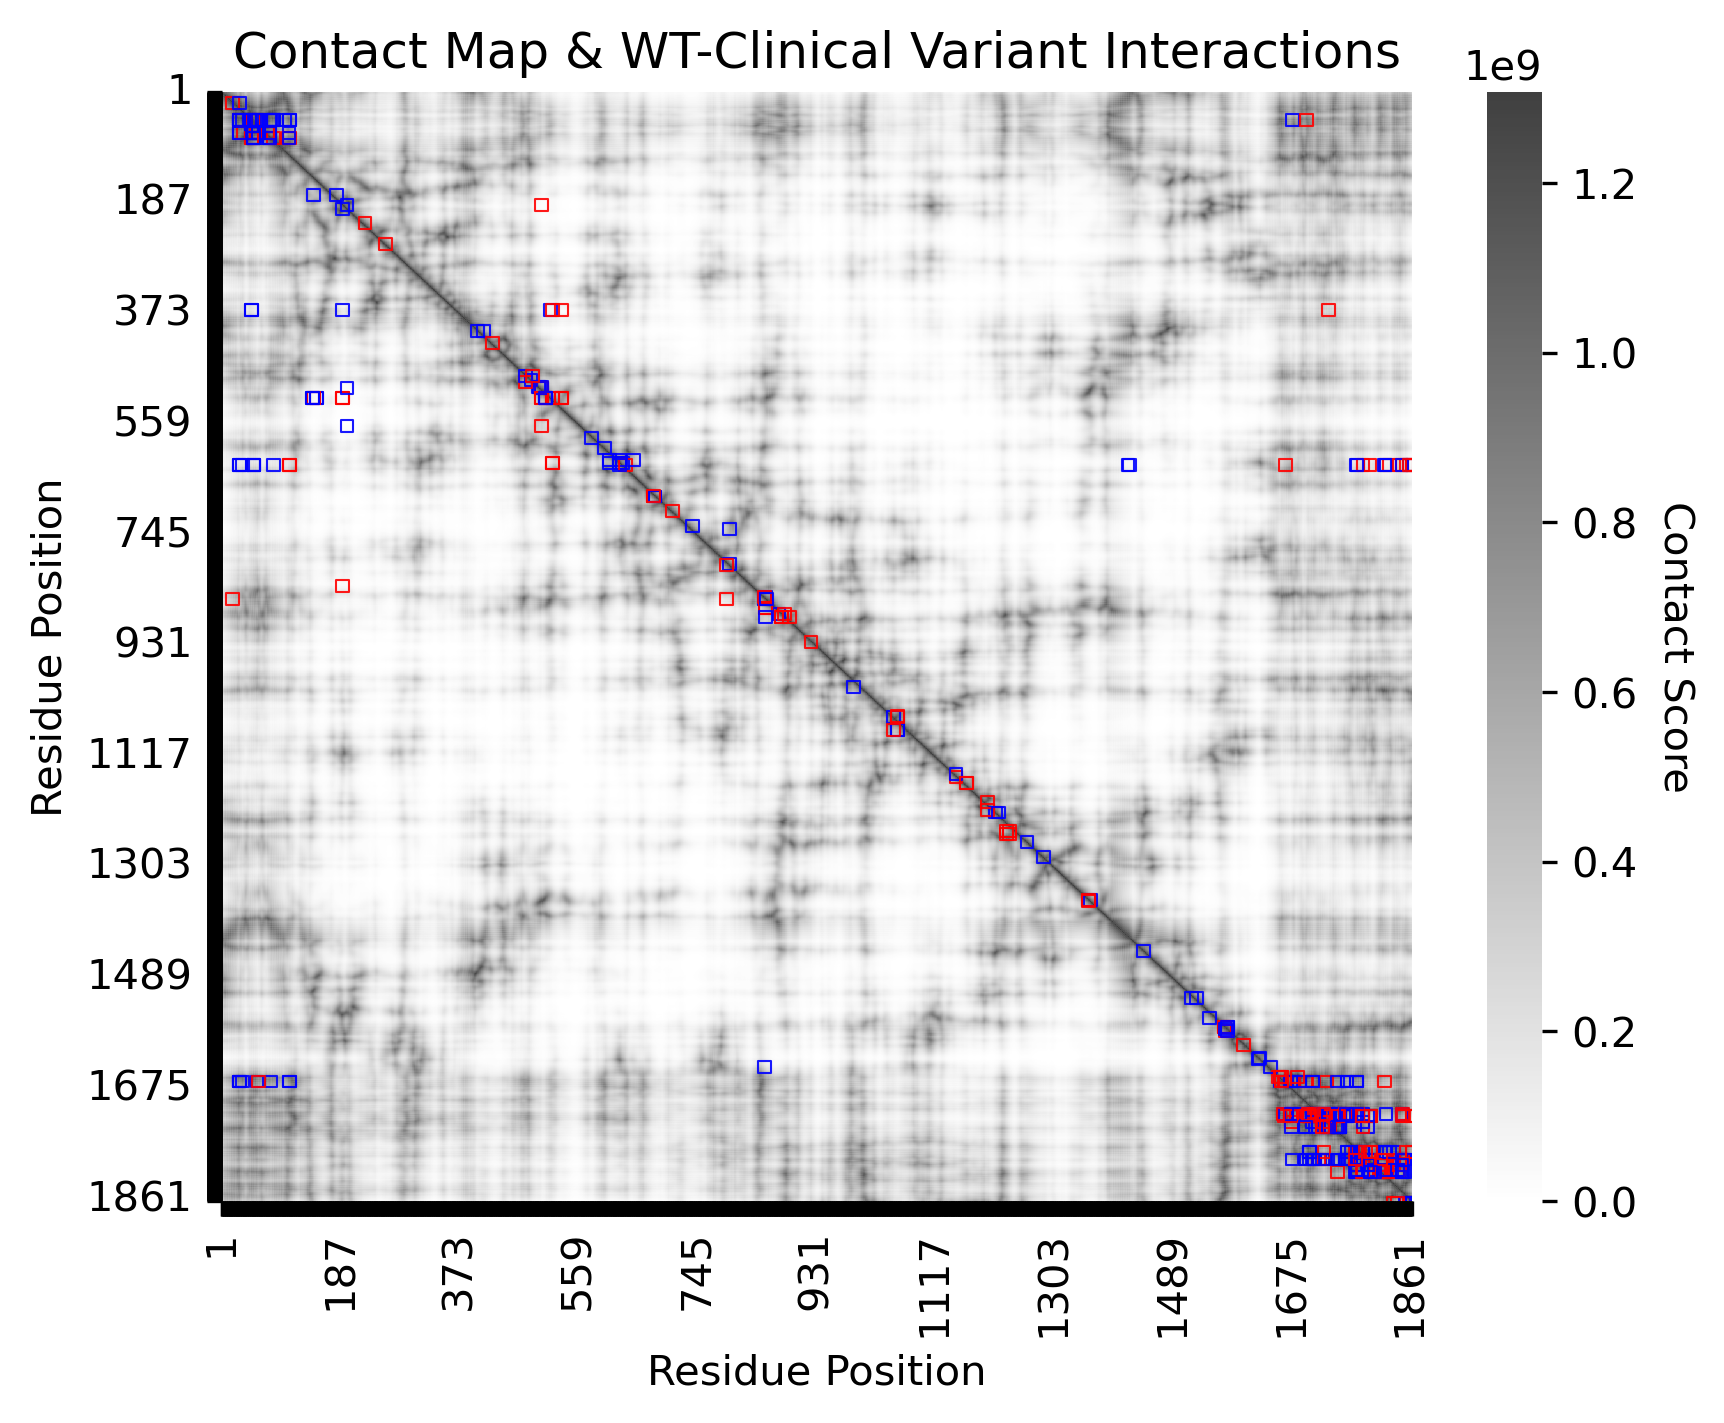

In [45]:
plot_contact_and_sensitization_maps_out = ab.plot_contact_and_sensitization_maps(
    contact_map_binned=contact_map_ref_binned,
    outlier_sig=top_interactions, 
    heatmap_alpha=0.75,
    rectangles_cmap={"more pathogenic": "red", "more benign": "blue", "neutral": "grey"},
    title=rf"Contact Map & WT-Clinical Variant Interactions",# +"\n"+rf"(Interaction Strength $\geq$ {interaction_threshold})",
    show_plot=(False, True),
    # figsize=(10, 10)
)

### Figure 2D

Contact enrichment: outlier detection method

In [43]:
ridge_enrichment = ab.compute_enrichment_vs_threshold(
    outlier_df=ridge_df,
    contact_map_binary=contact_map_binary_ref, 
    num_thresholds=50,
    linear_sampling=False,  
    interaction_col="interaction_strength"
)

100%|██████████| 50/50 [00:02<00:00, 19.50it/s]


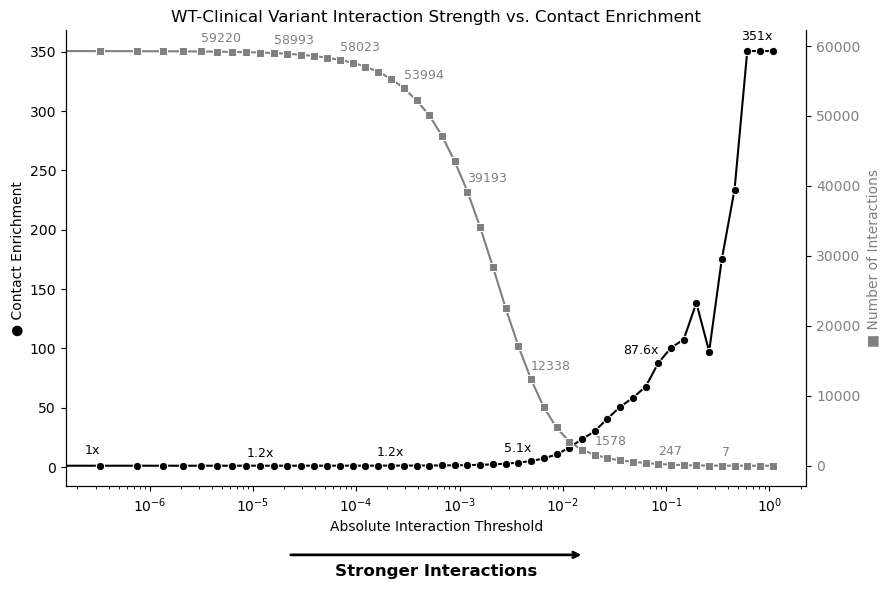

In [44]:
fig2d = ab.plot_enrichment_vs_interactions(ridge_enrichment,   
                                   log_x_axis=True, 
                                   y1_first_label=True,
                                   y1_last_label=True,
                                   y2_first_label=True,
                                   y2_last_label=True, )

### Figure 2E

Mean interaction strength per clinical variant.

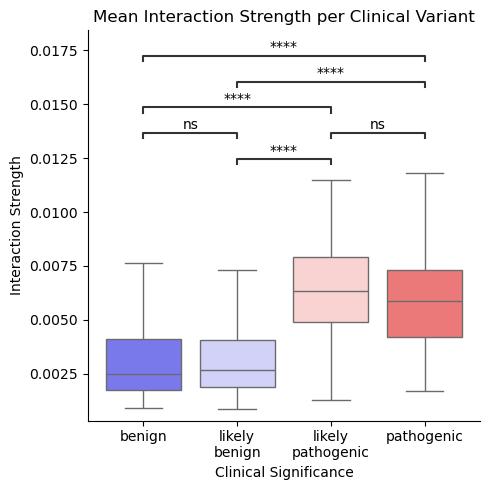

In [ ]:
fig2e = ab.plot_clinsig_interaction_strength(
    ridge_df, vep_prot,
    title="Mean Interaction Strength per Clinical Variant",
    xlabel="Clinical Significance",
    ylabel="Interaction Strength", 
    text_format="star",
    figsize=(5, 5),
)

### Figure 2F

Personalized contact maps vs. REF contact map.

In [91]:
#### Import from local AlphaFold files that I generated myself ####
pdb_files = cf.search_files(base_dir =  os.path.expanduser("~/projects/data/colabfold"),
                            tx_id = tx_id,
                            subdir = "af2_sameMSA",
                            suffix = ".pdb*",
                            model_number = 1 ) 

contact_maps = cf.import_contact_maps(pdb_files,
                                        return_distance_map=True,
                                        continuous=True)  

126 PDB files found


  0%|          | 0/126 [00:00<?, ?it/s]

100%|██████████| 126/126 [00:32<00:00,  3.92it/s]


### Figure 2G

Create population-weighted contact maps

For each superpopulation, weight the contacts maps according to their frequency in those populations.

In [92]:
contact_maps_binary = cf.import_contact_maps(pdb_files,
                                             return_distance_map=False,
                                             continuous=False)

100%|██████████| 126/126 [00:31<00:00,  3.96it/s]


In [ ]:
haplotypes_hgdp = hs.get_haplotypes(cache = hs.DIR_DICT["HGDP_haplotypes"],
                                     tx_ids=tx_id, 
                                    cache_only = True) 
haplotypes_1kg = hs.get_haplotypes(cache = hs.DIR_DICT["haplotypes"],
                                    tx_ids=tx_id, 
                                    cache_only = True) 
haplotypes = hs.merge_haplotype_datasets({"1KG":haplotypes_1kg, "HGDP":haplotypes_hgdp},
                                         tx_id_method = "intersection",
                                         use_deepcopy = True)

# Get a merged FASTA file
merged_fasta = hs.haplotypes_to_fasta(haplotypes=haplotypes,  
                        tx_ids=[tx_id],
                        save_dir=os.path.expanduser(f"~/projects/data/colabfold/{tx_id}"), 
                        split_subdir="",
                        # force=True,
                        compress=False) 

# Insert or add padding to each contact map (using the MSA as a guide)to make them all the same length
msa = bp.read_msa(merged_fasta[list(merged_fasta.keys())[0]], to_msa=True)
contact_maps_binary = cf.pad_all_contact_maps_to_msa(contact_maps=contact_maps_binary, 
                                                     msa=msa) 


Found haplotypes of 85520 transcripts in: '/home/schilder/projects/data/Human_Genome_Diversity_Project/haplosaurus/'


Getting haplotypes:   0%|          | 0/1 [00:00<?, ?it/s]

Found haplotypes of 47329 transcripts in: '/home/schilder/.cache/ensembl_rest/haplotypes/'


Getting haplotypes:   0%|          | 0/1 [00:00<?, ?it/s]

Using deepcopy
Merging 1 tx_ids using intersection


Merging haplotype datasets:   0%|          | 0/2 [00:00<?, ?it/s]

Merging haplotypes:   0%|          | 0/1 [00:00<?, ?it/s]

Getting haplotype names:   0%|          | 0/1 [00:00<?, ?it/s]

Merged 144 haplotypes across 1 tx_ids.


In [97]:
haps_to_samples = hs.haplotypes_to_samples(haplotypes=haplotypes,  
                                           as_df=True,
                                           add_sample_metadata=True,
                                           return_seqs=False, 
                                           add_ref=False, 
                                           duplicate_ref=False,
                                           verbose=True,
                                           )

freq_df = hs.calculate_haplotype_frequency_per_superpop(
    haps_to_samples,
    cast=True, 
    verbose=True,
    add_specificity_cols=True
)
freq_df.head()

Extracting sample IDs:   0%|          | 0/1 [00:00<?, ?it/s]

Number of samples: 3938
Number of transcripts to process: 1


Processing sample to haplotype name maps:   0%|          | 0/1 [00:00<?, ?it/s]

Converting haplotypes to DataFrame
Adding sample metadata to the DataFrame
0 samples are missing superpopulation metadata
Samples before merging: 3826
Samples after merging: 3826
Final shape: (7860, 16)
>> haplotype(s): 144
>> cohort(s): 3
>> cohort_sample(s): 3938
>> sample(s): 3826
>> population(s): 158
>> superpopulation(s): 8
>> sex(s): 2
0 samples are missing superpopulation metadata

Number of variants specific to each superpopulation:
specific_superpopulation
AFR    41
EAS    20
SAS    16
AMR    14
EUR    13
MID     8
OCE     4
CSA     2
Name: count, dtype: int64

Percentage of superpopulation-specific haplotypes: 81.94%


,haplotype,AFR_freq,AMR_freq,CSA_freq,EAS_freq,EUR_freq,MID_freq,OCE_freq,SAS_freq,AFR_samples,AMR_samples,CSA_samples,EAS_samples,EUR_samples,MID_samples,OCE_samples,SAS_samples,top_superpopulation,top_superpopulation_freq,superpopulation_count,specific_superpopulation,specific_superpopulation_samples
0,ENSP00000350283:1028R>H,0.000000,0.004902,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0,AMR,0.004902,1,AMR,4.0
1,"ENSP00000350283:1038E>G,1183K>R,1613S>G",0.000000,0.000000,0.0,0.0,0.000000,0.003289,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,MID,0.003289,1,MID,1.0
2,"ENSP00000350283:1038E>G,1613S>G",0.000000,0.000000,0.0,0.0,0.003012,0.003289,0.0,0.000000,0.0,0.0,0.0,0.0,4.0,1.0,0.0,0.0,MID,0.003289,2,None,NaN
3,ENSP00000350283:1040S>N,0.000791,0.017157,0.0,0.0,0.020331,0.006579,0.0,0.000992,2.0,14.0,0.0,0.0,27.0,2.0,0.0,1.0,EUR,0.020331,5,None,NaN
4,ENSP00000350283:1099P>L,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.002976,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,SAS,0.002976,1,SAS,3.0


In [161]:
pop_contact_maps = cf.compute_population_specific_contact_maps(
    contact_maps=contact_maps,
    contact_maps_binary=contact_maps_binary,
    freq_df=freq_df, 
    superpopulation_specific_only=False,
    exclude_ref_from_weights=True,
    weight_binary_maps=True,
)
specific_maps = pop_contact_maps["specific_maps"]
specific_diff_maps = pop_contact_maps["specific_diff_maps"]
specific_binary_diff_maps = pop_contact_maps["specific_binary_diff_maps"]
specific_binary_diff_figs = pop_contact_maps["specific_binary_diff_figs"]

100%|██████████| 8/8 [00:22<00:00,  2.81s/it]


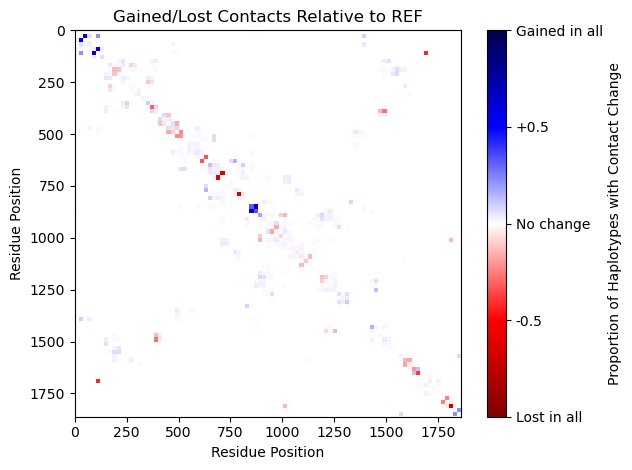

(<Figure size 640x480 with 2 Axes>,
 array([[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]], shape=(1863, 1863)))

In [ ]:
fig1g = cf.plot_contact_map_diff(contact_maps_binary,  
                                weights=None,
                                show_plot=True,
                                verbose=False)

In [231]:
%%capture

fig_superop_diff = cf.plot_superpopulation_contact_diff(
    specific_binary_diff_figs,
    specific_binary_diff_maps, 
    use_common_heatmap_scale=True,
    set_common_barplot_ylim=True,
    show_plot=False
)

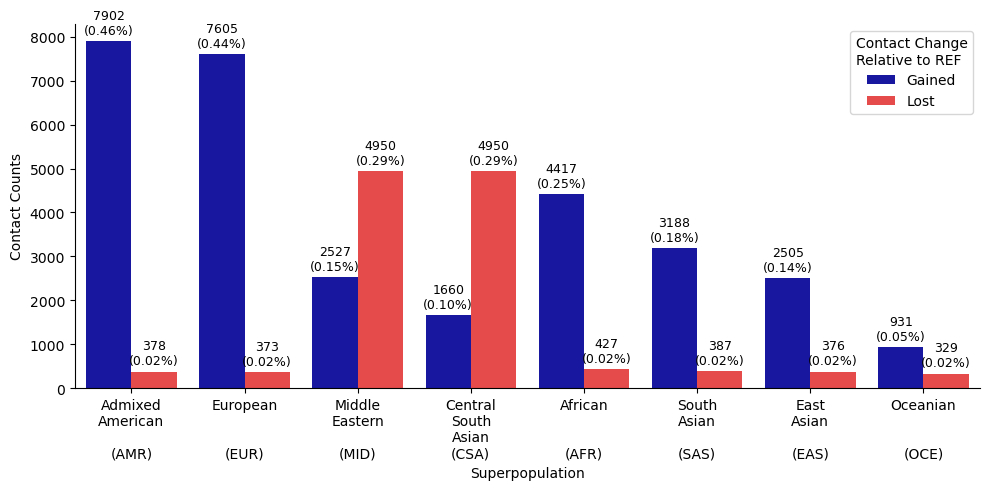

In [ ]:
fig2h = cf.plot_contact_map_diff_barplot_grouped(
    bar_df=fig_superop_diff['data'],
    group_by="superpopulation", 
    )

## Figure 3

In [2]:
lr_dict = {} 
lr_gene_dict = {}
min_values_per_label= 10

### Figure 3A

ESM

In [3]:
# Gather data from each model and compute logreg results

#### Run for all models ####
from IPython.display import clear_output
force = False

for model_location in va.list_all_models():
    print(f"Processing {model_location}") 
    save_path = os.path.join("results/data/","vep_df_"+model_location+".parquet")
    
    if os.path.exists(save_path) and not force:
        print(f"Loading {save_path}")
        vep_tmp = pd.read_parquet(save_path)
    else:
        vep_files_model = va.list_vep_files(model_location=model_location, as_df=True)
        vep_tmp = va.merge_vep(add_metadata=True, 
                                scoring_strategy=["masked-marginals"], 
                                vep_files=vep_files_model
                                )
        print(f"Saving {save_path}")
        vep_tmp.to_parquet(save_path)

    # Run logreg analysis
    lr_dict[model_location] = bcv.run_clinvar_logreg_analysis(vep_tmp, 
                                                                clinsig_col="clinsig",
                                                                site_col="site") 

    lr_gene_dict[model_location] = bcv.run_clinvar_logreg_analysis_by_group(vep_tmp, 
                                                group_by="protein",
                                                vep_col="VEP",
                                                clinsig_col="clinsig",
                                                min_values_per_label=min_values_per_label,
                                                site_col="site" ) 
    clear_output()
del vep_tmp

#### Run for just the main ESM model ####
# lr_dict[model_name] = bcv.run_clinvar_logreg_analysis(vep_df, 
#                                             clinsig_col="clinsig",
#                                             site_col="site") 
# lr_gene_dict[model_name] = bcv.run_clinvar_logreg_analysis_by_group(vep_df, 
#                                                 group_by="protein",
#                                                 vep_col="VEP",
#                                                 clinsig_col="clinsig",
#                                                 min_values_per_label=min_values_per_label,
#                                                 site_col="site" )
    

### Figure 3B

SpliceAI

In [ ]:
spliceai_df_path = "../data/1000_Genomes_on_GRCh38/SpliceAI/spliceai_clinvar_merged.parquet"
spliceai_df = pd.read_parquet(spliceai_df_path)
spliceai_df["protein"] = spliceai_df["gene"]

In [58]:
lr_dict['SpliceAI'] = bcv.run_clinvar_logreg_analysis(spliceai_df, 
                                                        clinsig_col="CLNSIG_simplified",
                                                        site_col="site")  

Running logistic regression for REF
Running logistic regression for non-REF


In [78]:
lr_gene_dict['SpliceAI']= bcv.run_clinvar_logreg_analysis_by_group(spliceai_df, 
                                                                    group_by="protein",
                                                                    vep_col="VEP",
                                                                    clinsig_col="CLNSIG_simplified",
                                                                    min_values_per_label=min_values_per_label)

Groups:   0%|          | 0/1836 [00:00<?, ?it/s]

/home/schilder/.conda/envs/esm2/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/schilder/.conda/envs/esm2/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/schilder/.conda/envs/esm2/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize

### Figure 3C

Flashzoi

In [ ]:
variant_set="clinvar_utr_snv"
xr_mfds_dir=os.path.join(
    os.path.expanduser('~'),
    "projects/data/1000_Genomes_on_GRCh38",
    variant_set
) 
pq_file = os.path.join(xr_mfds_dir, "vep_df.parquet")

flashzoi_df = pd.read_parquet(pq_file)
if "VEP" not in flashzoi_df.columns:
    flashzoi_df["VEP"] = flashzoi_df["flashzoi_norm"] 
if "site" not in flashzoi_df.columns:
    flashzoi_df.rename(columns={"site_x": "site"}, inplace=True)
flashzoi_df["protein"] = flashzoi_df["GENE"] 

,index,site_x,sample,ploid,slot,evo2_40b_base,evo2_40b,evo2_7b_base,spliceai,evo2_7b,dnabert2,spliceai_mm,flashzoi,chrom,chromStart,chromEnd,name,score,REF,ALT,MC_id,MC_term,AF_ESP,AF_EXAC,AF_TGP,ALLELEID,CLNDISDB,CLNDN,CLNHGVS,CLNREVSTAT,CLNSIG,CLNVC,CLNVCSO,CLNSIGCONF,GENEINFO,MC,ORIGIN,RS,ONC,ONCDN,ONCDISDB,ONCREVSTAT,ONCCONF,SCI,SCIDN,SCIDISDB,SCIREVSTAT,CLNREVSTAT_score,site_y,MONDO,MONDO_n,OMIM,OMIM_n,Orphanet,Orphanet_n,MedGen,MedGen_n,MeSH,MeSH_n,CLNSIG_simple,CLNSIG_super_simple,GENE,flashzoi_norm,VEP
0,0,chr20:23047426-23047427_T_C,REF,0,COVR,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.730848,20,23047426,23047427,chr20:23047426-23047427_T_C,2.0,T,C,SO:0001624,3_prime_UTR_variant,NaN,NaN,0.01917,350732,"MONDO:MONDO:0013044,MedGen:C2752036,OMIM:61292...",Atypical_hemolytic-uremic_syndrome_with_thromb...,NC_000020.11:g.23047426T>C,"criteria_provided,_multiple_submitters,_no_con...",Benign,single_nucleotide_variant,SO:0001483,None,THBD:7056,SO:0001624|3_prime_UTR_variant,1,11696919.0,None,None,None,None,None,None,None,None,None,2,chr20:23047426-23047427_T_C,[MONDO:MONDO:0013044],1,[OMIM:612926],1,[],0,"[MedGen:C2752036, MedGen:C3661900]",2,[],0,benign,benign,THBD,-0.174794,-0.174794
1,14,chr20:23047426-23047427_T_C,REF,1,COVR,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.592481,20,23047426,23047427,chr20:23047426-23047427_T_C,2.0,T,C,SO:0001624,3_prime_UTR_variant,NaN,NaN,0.01917,350732,"MONDO:MONDO:0013044,MedGen:C2752036,OMIM:61292...",Atypical_hemolytic-uremic_syndrome_with_thromb...,NC_000020.11:g.23047426T>C,"criteria_provided,_multiple_submitters,_no_con...",Benign,single_nucleotide_variant,SO:0001483,None,THBD:7056,SO:0001624|3_prime_UTR_variant,1,11696919.0,None,None,None,None,None,None,None,None,None,2,chr20:23047426-23047427_T_C,[MONDO:MONDO:0013044],1,[OMIM:612926],1,[],0,"[MedGen:C2752036, MedGen:C3661900]",2,[],0,benign,benign,THBD,-0.472828,-0.472828
2,28,chr20:23047426-23047427_T_C,HG00096,0,COVR,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.695581,20,23047426,23047427,chr20:23047426-23047427_T_C,2.0,T,C,SO:0001624,3_prime_UTR_variant,NaN,NaN,0.01917,350732,"MONDO:MONDO:0013044,MedGen:C2752036,OMIM:61292...",Atypical_hemolytic-uremic_syndrome_with_thromb...,NC_000020.11:g.23047426T>C,"criteria_provided,_multiple_submitters,_no_con...",Benign,single_nucleotide_variant,SO:0001483,None,THBD:7056,SO:0001624|3_prime_UTR_variant,1,11696919.0,None,None,None,None,None,None,None,None,None,2,chr20:23047426-23047427_T_C,[MONDO:MONDO:0013044],1,[OMIM:612926],1,[],0,"[MedGen:C2752036, MedGen:C3661900]",2,[],0,benign,benign,THBD,-0.250758,-0.250758
3,42,chr20:23047426-23047427_T_C,HG00096,1,COVR,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.638817,20,23047426,23047427,chr20:23047426-23047427_T_C,2.0,T,C,SO:0001624,3_prime_UTR_variant,NaN,NaN,0.01917,350732,"MONDO:MONDO:0013044,MedGen:C2752036,OMIM:61292...",Atypical_hemolytic-uremic_syndrome_with_thromb...,NC_000020.11:g.23047426T>C,"criteria_provided,_multiple_submitters,_no_con...",Benign,single_nucleotide_variant,SO:0001483,None,THBD:7056,SO:0001624|3_prime_UTR_variant,1,11696919.0,None,None,None,None,None,None,None,None,None,2,chr20:23047426-23047427_T_C,[MONDO:MONDO:0013044],1,[OMIM:612926],1,[],0,"[MedGen:C2752036, MedGen:C3661900]",2,[],0,benign,benign,THBD,-0.373023,-0.373023
4,56,chr20:23047426-23047427_T_C,HG00097,0,COVR,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.546913,20,23047426,23047427,chr20:23047426-23047427_T_C,2.0,T,C,SO:0001624,3_prime_UTR_variant,NaN,NaN,0.01917,350732,"MONDO:MONDO:0013044,MedGen:C2752036,OMIM:61292...",Atypical_hemolytic-uremic_syndrome_with_thromb...,NC_000020.11:g.23047426T>C,"criteria_provided,_multiple_submitters,_no_con...",Benign,single_nucleotide_variant,SO:0001483,None,THBD:7056,SO:0001624|3_prime_UTR_variant,1,11696919.0,None,None,None,None,None,None,None,None,None,2,chr20:23047426-23047427_T_C,[MONDO:MONDO:0013044],1,[OMIM:612926],1,[],0,"[MedGen:C2752036, MedGen:C3661900]",2,[],0,benign,benign,THBD,-0.570978,-0.570978


In [68]:
lr_dict['Flashzoi'] = bcv.run_clinvar_logreg_analysis(flashzoi_df, 
                                                        clinsig_col="CLNSIG_simple",
                                                        site_col="site") 

Running logistic regression for REF
Running logistic regression for non-REF


In [77]:
lr_gene_dict['Flashzoi'] = bcv.run_clinvar_logreg_analysis_by_group(flashzoi_df, 
                                                                    group_by="protein",
                                                                    vep_col="VEP",
                                                                    clinsig_col="CLNSIG_simple",
                                                                    min_values_per_label=min_values_per_label)

Groups:   0%|          | 0/1464 [00:00<?, ?it/s]

/home/schilder/.conda/envs/esm2/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/schilder/.conda/envs/esm2/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/schilder/.conda/envs/esm2/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize

Uncorrected for gene bias.

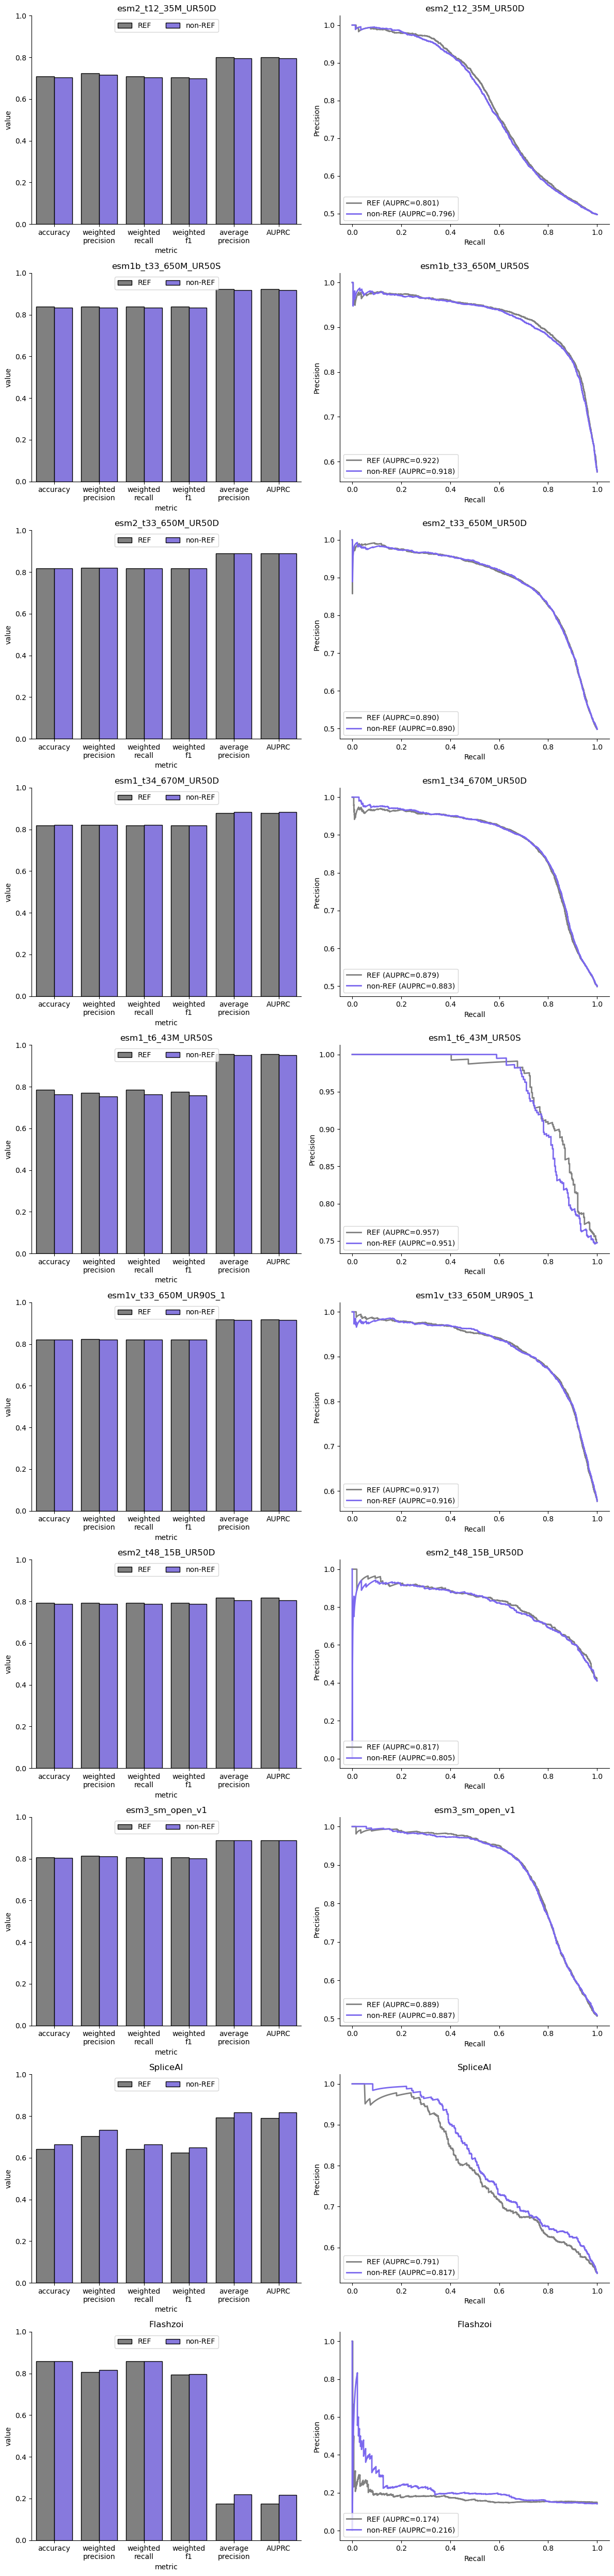

{'fig': <Figure size 1200x5000 with 20 Axes>,
 'axes': array([[<Axes: title={'center': 'esm2_t12_35M_UR50D'}, xlabel='metric', ylabel='value'>,
         <Axes: title={'center': 'esm2_t12_35M_UR50D'}, xlabel='Recall', ylabel='Precision'>],
        [<Axes: title={'center': 'esm1b_t33_650M_UR50S'}, xlabel='metric', ylabel='value'>,
         <Axes: title={'center': 'esm1b_t33_650M_UR50S'}, xlabel='Recall', ylabel='Precision'>],
        [<Axes: title={'center': 'esm2_t33_650M_UR50D'}, xlabel='metric', ylabel='value'>,
         <Axes: title={'center': 'esm2_t33_650M_UR50D'}, xlabel='Recall', ylabel='Precision'>],
        [<Axes: title={'center': 'esm1_t34_670M_UR50D'}, xlabel='metric', ylabel='value'>,
         <Axes: title={'center': 'esm1_t34_670M_UR50D'}, xlabel='Recall', ylabel='Precision'>],
        [<Axes: title={'center': 'esm1_t6_43M_UR50S'}, xlabel='metric', ylabel='value'>,
         <Axes: title={'center': 'esm1_t6_43M_UR50S'}, xlabel='Recall', ylabel='Precision'>],
        [<Axes:

In [86]:
bcv.plot_logreg_results_subplots(
    data_dict = lr_dict,
    figsize = (12, 5),   
)

Corrected for gene bias.

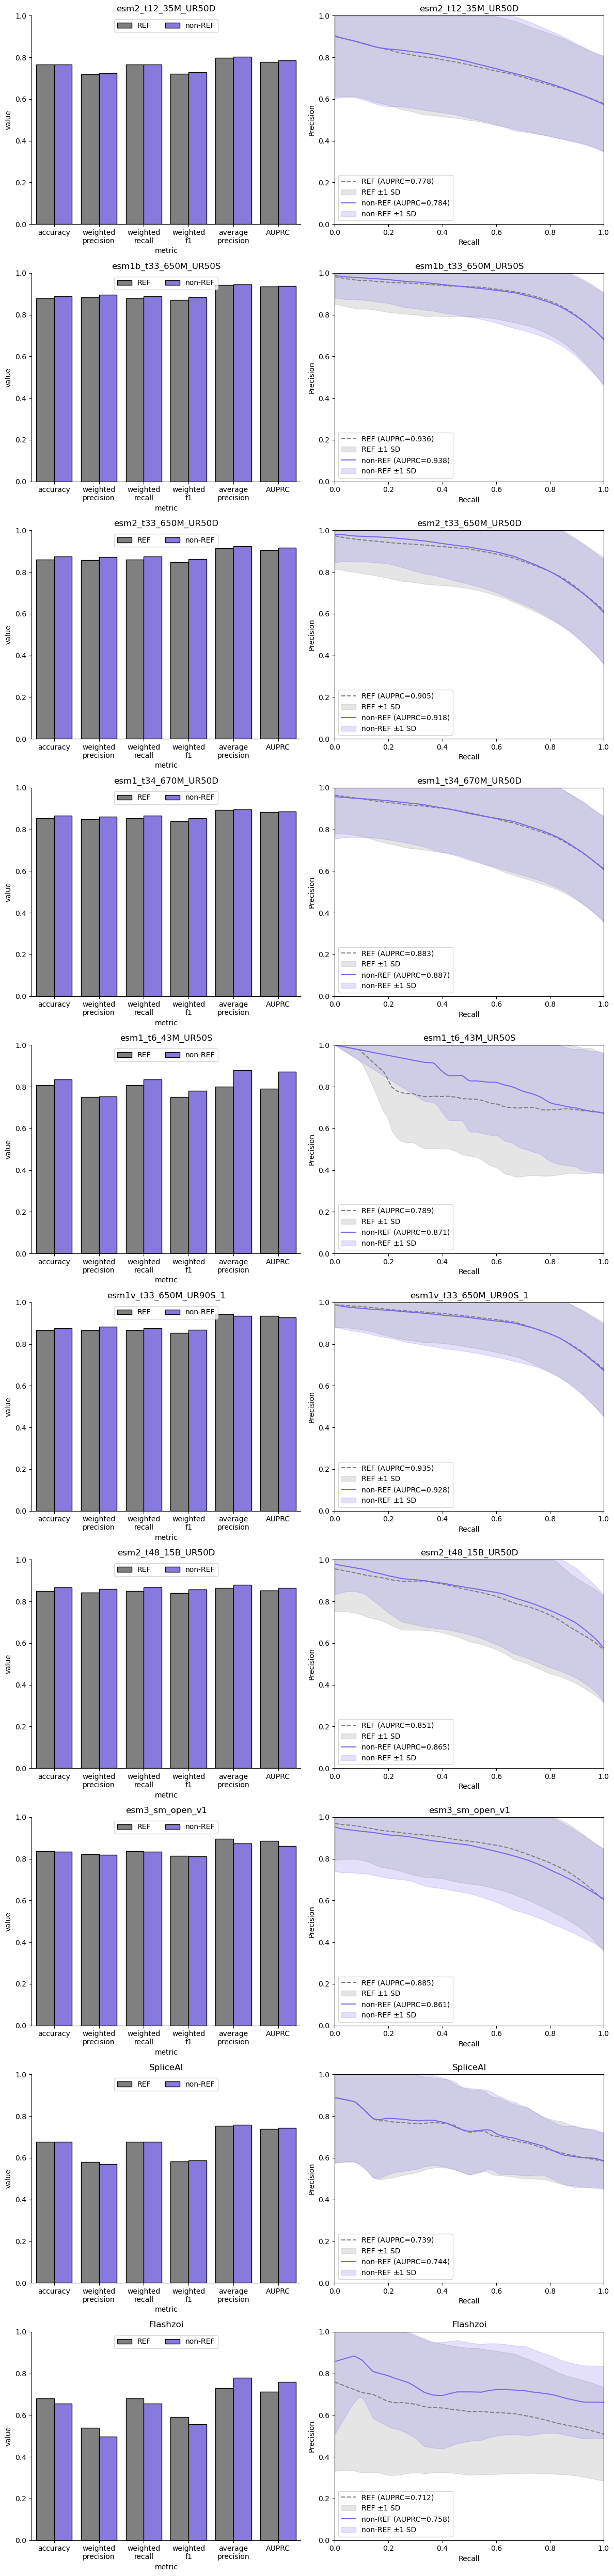

{'fig': <Figure size 1200x5000 with 20 Axes>,
 'axes': array([[<Axes: title={'center': 'esm2_t12_35M_UR50D'}, xlabel='metric', ylabel='value'>,
         <Axes: title={'center': 'esm2_t12_35M_UR50D'}, xlabel='Recall', ylabel='Precision'>],
        [<Axes: title={'center': 'esm1b_t33_650M_UR50S'}, xlabel='metric', ylabel='value'>,
         <Axes: title={'center': 'esm1b_t33_650M_UR50S'}, xlabel='Recall', ylabel='Precision'>],
        [<Axes: title={'center': 'esm2_t33_650M_UR50D'}, xlabel='metric', ylabel='value'>,
         <Axes: title={'center': 'esm2_t33_650M_UR50D'}, xlabel='Recall', ylabel='Precision'>],
        [<Axes: title={'center': 'esm1_t34_670M_UR50D'}, xlabel='metric', ylabel='value'>,
         <Axes: title={'center': 'esm1_t34_670M_UR50D'}, xlabel='Recall', ylabel='Precision'>],
        [<Axes: title={'center': 'esm1_t6_43M_UR50S'}, xlabel='metric', ylabel='value'>,
         <Axes: title={'center': 'esm1_t6_43M_UR50S'}, xlabel='Recall', ylabel='Precision'>],
        [<Axes:

In [85]:
bcv.plot_logreg_gene_subplots(
    data_dict = lr_gene_dict,
    figsize = (12, 5) 
)

---

---

## Figure S1

Plot VEP distributions for each combination of model and scoring strategy.

Protein sequence models.

In [ ]:
force = False
groupby_cols = ['model_location','protein','clinsig','mutant','scoring_strategy'] 
vep_agg =[]
for model_location in va.list_all_models():

    print(f"Processing {model_location}")
    save_path = os.path.join("results/data/","vep_df_"+model_location+".parquet")
    
    if os.path.exists(save_path) and not force:
        print(f"Loading {save_path}")
        vep_tmp = pd.read_parquet(save_path)
    else:
        vep_files_model = va.list_vep_files(model_location=model_location, as_df=True)
        vep_tmp = va.merge_vep(add_metadata=True, 
                                scoring_strategy=["masked-marginals"], 
                                vep_files=vep_files_model
                                )
        print(f"Saving {save_path}")
        vep_tmp.to_parquet(save_path)
    vep_agg.append(vep_tmp.groupby(groupby_cols, observed=True)["VEP"].mean().reset_index())
     

vep_agg = pd.concat(vep_agg)
vep_agg.head()

Filtered 0.2% of rows with NAs in col 'VEP'


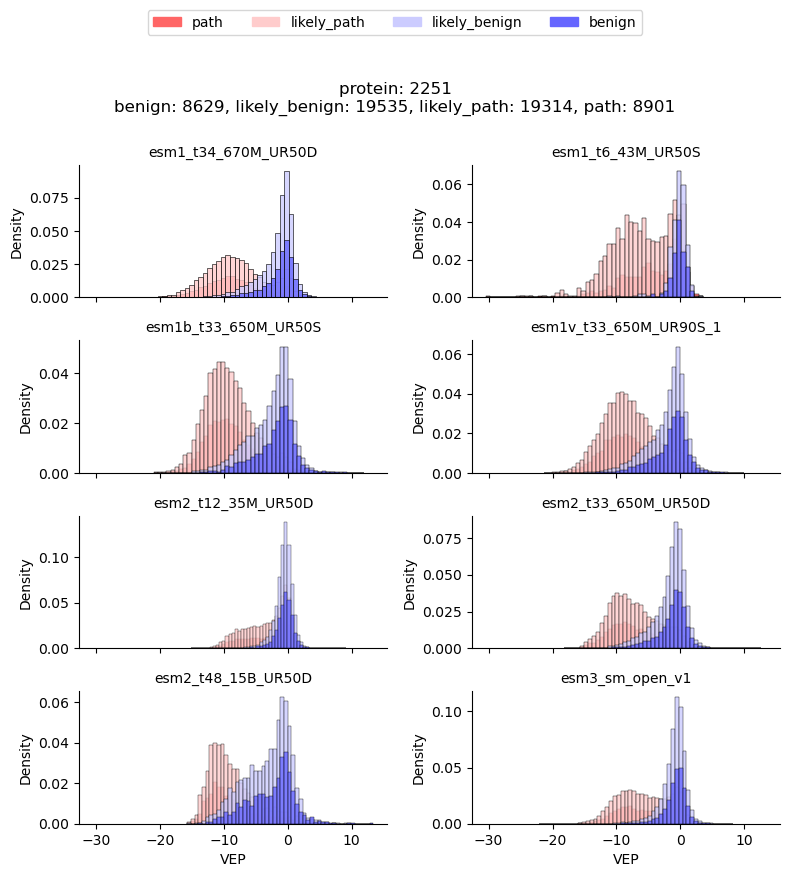

In [ ]:
va.plot_vep_density(vep_agg.sort_values(by='model_location'), 
                     multiple=['layer','stack','fill'][0],
                     row=None,
                     col='model_location',    
                     plot_func=sns.histplot,
                     stat='density',
                     bins=50,
                     facetgrid_kwargs={'col_wrap': 2}, 
                     height=2,
                     aspect=2,
                     save_path="results/plots/vep_density.png"
                     )

DNA sequence models.

Flashzoi

In [87]:
clnsig_map = {"likely_pathogenic": "likely_path",
                    "pathogenic": "path", 
                    "benign": "benign",
                    "vus": "VUS",
                    "likely_benign": "likely_benign"}

vep_dna_agg = [] 
flashzoi_df.rename(columns={"site_x":"site"}, inplace=True)
flashzoi_df["VEP"] = flashzoi_df["flashzoi_norm"]
flashzoi_df["clinsig"] = flashzoi_df["CLNSIG_simple"]#.map(clnsig_map)
agg = flashzoi_df.groupby(['site','clinsig'], observed=True)["VEP"].mean().reset_index()
agg["model_location"] = "Flashzoi"
vep_dna_agg.append(agg)

spliceai_df["clinsig"] = spliceai_df["CLNSIG_simplified"].map(clnsig_map)
agg = spliceai_df.groupby(['site','clinsig'], observed=True)["VEP"].mean().reset_index()
agg["model_location"] = "SpliceAI"
vep_dna_agg.append(agg)

vep_dna_agg = pd.concat(vep_dna_agg, ignore_index=True)
vep_dna_agg.head()

,site,clinsig,VEP,model_location
0,chr11:10294187-10294188_C_A,likely_benign,0.981774,Flashzoi
1,chr11:10506578-10506579_A_G,benign,0.030980,Flashzoi
2,chr11:10506936-10506937_A_G,benign,0.057640,Flashzoi
3,chr11:10506954-10506955_A_G,benign,0.459897,Flashzoi
4,chr11:10506974-10506975_A_G,benign,0.005592,Flashzoi


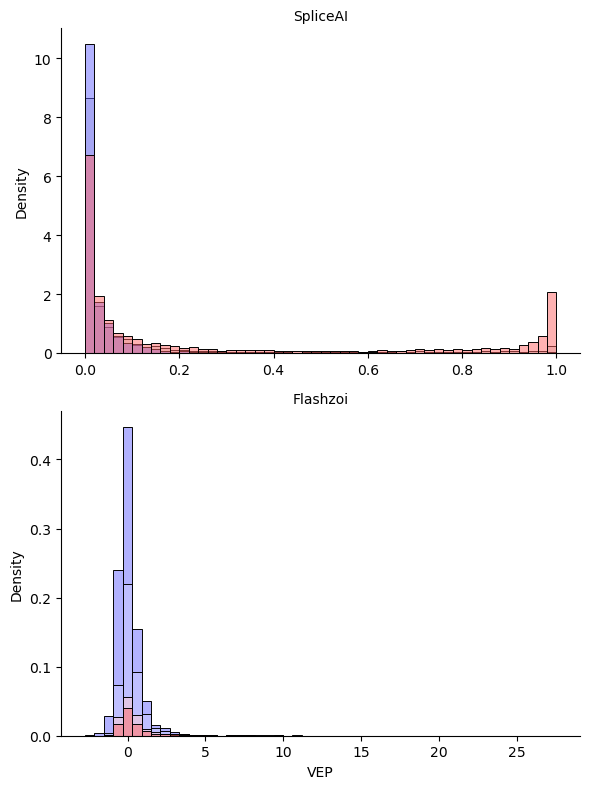

In [109]:
palette = utils.get_clinsig_palette() 
vep_dna_agg = utils.sort_by_clinsig(vep_dna_agg)

g1= sns.FacetGrid(
    vep_dna_agg,
    col="model_location",
    col_wrap=1,
    height=4,
    aspect=1.5,
    sharex=False,
    sharey=False,
    legend_out=False  # Set to False so legend is drawn on the facet
)
g1.map_dataframe(
    sns.histplot,
    x="VEP",
    hue="clinsig",
    palette=palette,
    multiple="layer",
    stat="density",
    bins=50,
    legend=True
)
va.rm_subplot_prefixes(g1)
# Show legend for each facet
for ax in g1.axes.flat:
    handles, labels = ax.get_legend_handles_labels()
    if handles:
        ax.legend(handles, labels, title="clinsig")
g1.figure.tight_layout()

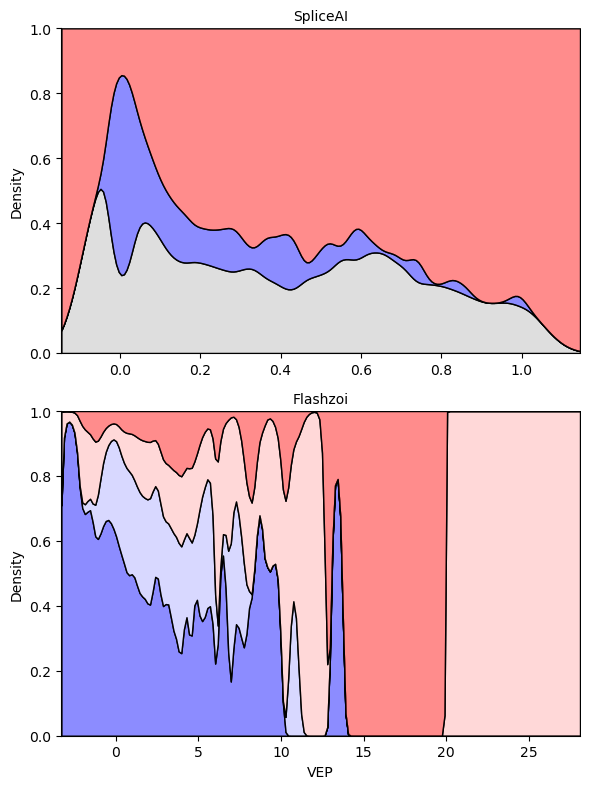

In [106]:
palette = utils.get_clinsig_palette() 
vep_dna_agg = utils.sort_by_clinsig(vep_dna_agg)

g2 = sns.FacetGrid(
    vep_dna_agg,
    col="model_location",
    col_wrap=1,
    height=4,
    aspect=1.5,
    sharex=False,
    sharey=False,
    legend_out=False  # Set to False so legend is drawn on the facet
)
g2.map_dataframe(
    sns.kdeplot,
    x="VEP",
    hue="clinsig",
    multiple="fill",
    fill=True,
    palette=palette, 
    legend=True
)
va.rm_subplot_prefixes(g2)
# Show legend for each facet
for ax in g2.axes.flat:
    handles, labels = ax.get_legend_handles_labels()
    if handles:
        ax.legend(handles, labels, title="clinsig")
g2.figure.tight_layout()

## Figure S2

In [265]:
vep_df = va.compute_representativeness_stats(vep_df, is_ref=False)

In [278]:
vep_df["n_haplotypes"] = vep_df.groupby(["model_location", "scoring_strategy", "mutant"])["haplotype"].transform("nunique")

In [ ]:
#### Violin plot version ####
# fig1f_vio = db.plot_vep_percentiles(vep_df, row=None, col=None, height=5, aspect=1.5, x_rotation=0, x_ha='center')

In [ ]:
groupby_cols = ['model_location','protein','clinsig','mutant','scoring_strategy']
normality_results = db.test_normality(vep_df,
                                      min_n=20,
                                      groupby_cols=groupby_cols)
normality_results.head()

  0%|          | 0/54433 [00:00<?, ?it/s]

metric,model_location,protein,clinsig,mutant,scoring_strategy,n_samples,pvalue,statistic
0,esm2_t33_650M_UR50D,NP_000007.1,benign,C159W,masked-marginals,26.0,0.288377,2.486977
1,esm2_t33_650M_UR50D,NP_000007.1,likely_benign,M87I,masked-marginals,26.0,0.000002,25.841743
2,esm2_t33_650M_UR50D,NP_000007.1,likely_path,A113T,masked-marginals,26.0,0.008392,9.560975
3,esm2_t33_650M_UR50D,NP_000007.1,likely_path,A165T,masked-marginals,26.0,0.000017,21.954090
4,esm2_t33_650M_UR50D,NP_000007.1,likely_path,A81T,masked-marginals,26.0,0.001276,13.327450


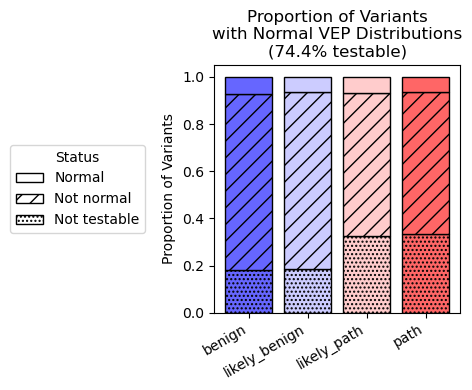

In [ ]:
plot_test_normality_out = db.plot_test_normality(normality_results, 
                                                 figsize=(5, 4), 
                                                 legend_left=True, 
                                                 )

<string>:31: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.


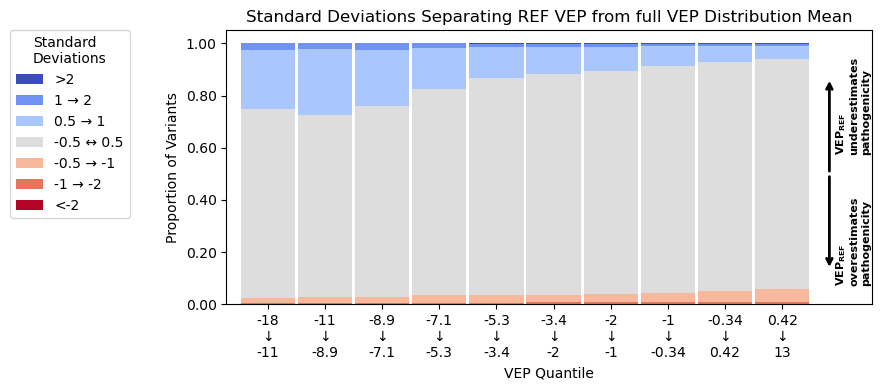

In [ ]:
#### Standard Deviation version ####

# Limit to variants with normal VEP distributions
groupby_cols = ['model_location','protein','clinsig','mutant','scoring_strategy']
vep_sub = vep_df.merge(
    normality_results.loc[normality_results["pvalue"] >= 0.05],
    on=groupby_cols,
    how="left"
) 
fig1f_std = db.plot_ref_vep_std_stacked_bar(vep_sub)

In [ ]:
fig1f_std['data'].groupby('VEP_pct_group_cat').size() / fig1f_std['data'].groupby('VEP_pct_group_cat').size().sum()*100

/tmp/ipykernel_3060468/3121036080.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  fig1f['data'].groupby('VEP_pct_group_cat').size() / fig1f['data'].groupby('VEP_pct_group_cat').size().sum()*100
/tmp/ipykernel_3060468/3121036080.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  fig1f['data'].groupby('VEP_pct_group_cat').size() / fig1f['data'].groupby('VEP_pct_group_cat').size().sum()*100


VEP_pct_group_cat
<-2            0.444569
-1 → -2        7.336782
-0.5 → -1     17.570250
-0.5 ↔ 0.5    59.183559
0.5 → 1       10.703201
1 → 2          4.504404
>2             0.257235
dtype: float64

## Figure S3

Sampling 6 rows from 5
                                  mutant  protein
model_location  scoring_strategy                 
esm3_sm_open_v1 masked-marginals       5        4


<string>:92: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
<string>:156: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


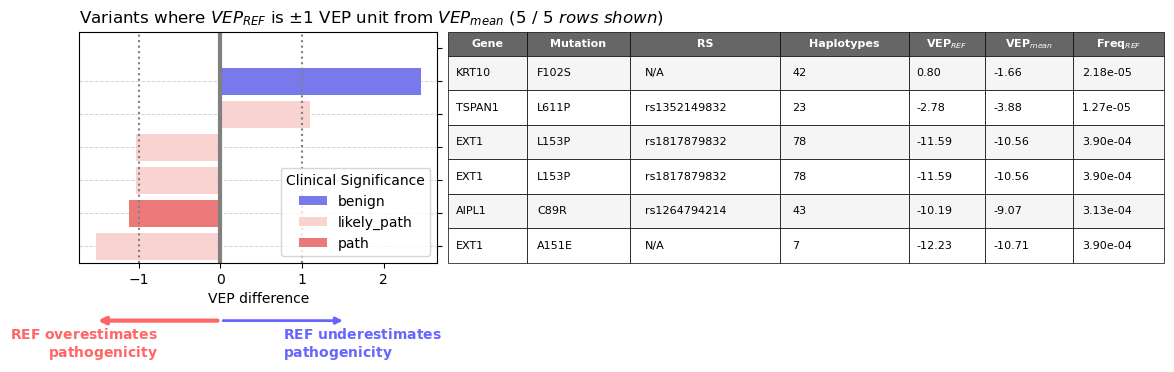

(<Axes: title={'left': 'Variants where $\\it{VEP_{REF}}$ is $\\pm$1 VEP unit from $\\it{VEP_{mean}}$$\\it{\\ (5\\ /\\ 5\\ rows\\ shown)}$'}, xlabel='VEP difference'>,
 <Axes: >)

In [458]:
va.plot_top_diff_variants(vep_df, 
                          freq_df, 
                          x="VEP_mean_diff", 
                          title=  r"Variants where $\it{VEP_{REF}}$ is $\pm$1 VEP unit from $\it{VEP_{mean}}$",
                          max_rows=6,
                          figsize=(14, None),
                          sample_head_and_tail=True,
                          arrow_bottom_margin=0.25,
                          arrow_text_padding=0.025,
                          table_width_ratio=2,
                          is_ref_filter=True)

Sampling 6 rows from 695
                                  mutant  protein
model_location  scoring_strategy                 
esm3_sm_open_v1 masked-marginals       6        5


<string>:91: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
<string>:155: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


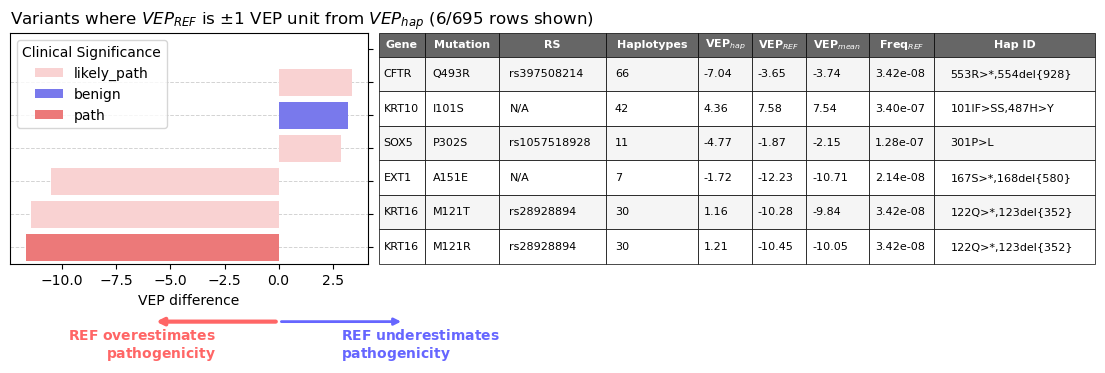

(<Axes: title={'left': 'Variants where $\\it{VEP_{REF}}$ is $\\pm$1 VEP unit from $\\it{VEP_{hap}}$ (6/695 rows shown)'}, xlabel='VEP difference'>,
 <Axes: >)

In [452]:
va.plot_top_diff_variants(vep_df, 
                          freq_df, 
                          x="VEP_ref_diff", 
                          title=  r"Variants where $\it{VEP_{REF}}$ is $\pm$1 VEP unit from $\it{VEP_{hap}}$",
                          max_rows=6,
                          figsize=(14, None),
                          sample_head_and_tail=True,
                          arrow_bottom_margin=0.25,
                          arrow_text_padding=0.025,
                          table_width_ratio=2,
                          is_ref_filter=None)

In [460]:
import matplotlib.pyplot as plt

# Create bins: '<-1', '-1 to 1', '>1'
bins = pd.cut(
    vep_df.loc[~vep_df["is_ref"], "VEP_ref_diff"],
    bins=[-float('inf'), -1, 1, float('inf')],
    labels=['<-1', '-1 to 1', '>1']
)
bin_counts = bins.value_counts().sort_index()
bin_counts
 

VEP_ref_diff
<-1           520
-1 to 1    521287
>1            180
Name: count, dtype: int64

## Figure S4

Proportion of gained/lost contacts per superpopulation: weighted proportional to haplotype frequency within each superpopulation.